# E-Commerce Sales Dashboard — EDA & Data Cleaning Framework

> **Goal:** Clean and explore the Amazon sales, customer sales, and product catalog datasets,  
> then engineer the features needed for **RFM analysis** and an **interactive dashboard**.

---

## Framework Phases
| Phase | Focus |
|-------|-------|
| 0 | Setup & Load |
| 1 | Initial Inspection |
| 2 | Data Quality Assessment |
| 3 | Data Cleaning |
| 4 | Feature Engineering |
| 5 | Univariate Analysis |
| 6 | Bivariate & Segment Analysis |
| 7 | RFM Analysis |
| 8 | Dashboard Prep & Export |

# Dataset Files

## 1. `amazon_sales_report.csv`
Main transactional sales dataset used for sales analytics and dashboard visualizations.

### Features

| Column | Description |
|---|---|
| Category | Product category/type |
| Size | Product size |
| Date | Date of sale |
| Status | Order/sale status |
| Fulfilment | Fulfillment method used |
| Style | Product style/design |
| SKU | Unique product identifier |
| ASIN | Amazon Standard Identification Number |
| Courier Status | Shipping/courier status |
| Qty | Quantity sold |
| Amount | Total transaction amount |
| B2B | Indicates whether transaction is business-to-business |
| Currency | Currency used in transaction |


---

# 2. `customer_sales.csv`
Customer-focused sales dataset used for RFM analysis and customer segmentation.

### Features

| Column | Description |
|---|---|
| Style | Product style/design |
| SKU | Unique product identifier |
| Size | Product size |
| DATE | Date of sale |
| Months | Month of sale |
| CUSTOMER | Customer name |
| PCS | Number of pieces sold |
| RATE | Price per piece |
| GROSS AMT | Total sales amount |

---

# 3. `product_catalog.csv`
Product metadata and inventory reference dataset.

### Features

| Column | Description |
|---|---|
| SKU Code | Unique product identifier |
| Design No. | Unique identifier for each product design |
| Stock | Number of items currently in stock |
| Category | Product category/type |
| Size | Product size |
| Color | Product color |

In [211]:
# ── Phase 0: Setup ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings


warnings.filterwarnings("ignore")
%matplotlib inline

# ── Display settings ───────────────────────────────────────────────────────────
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

# ── Plot theme ─────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
FIGSIZE = (12, 5)
COLOR_PRIMARY = "#4C72B0"

print("Setup complete")

Setup complete


In [212]:
# ── Load raw data ──────────────────────────────────────────────────────────────
amazon_raw   = pd.read_csv("csv/amazon_sales_report.csv", low_memory=False)
customer_raw = pd.read_csv("csv/customer_sales.csv",      low_memory=False)
catalog_raw  = pd.read_csv("csv/product_catalog.csv",     low_memory=False)

datasets = {
    "Amazon Sales":    amazon_raw,
    "Customer Sales":  customer_raw,
    "Product Catalog": catalog_raw,
}

for name, df in datasets.items():
    print(f"  {name:20s} → {df.shape[0]:,} rows × {df.shape[1]} cols")

print("\nAll datasets loaded")

  Amazon Sales         → 128,975 rows × 24 cols
  Customer Sales       → 37,432 rows × 10 cols
  Product Catalog      → 9,271 rows × 7 cols

All datasets loaded


---
## Phase 1 — Initial Inspection
> **Goal:** Get a feel for each dataset's shape, column names, dtypes, and a sample of the data before touching anything.

In [213]:
def inspect(df, name="DataFrame", n=3):
    """Quick structural overview of a dataframe."""
    print(f"{'─'*60}")
    print(f"  {name}  |  {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
    print(f"{'─'*60}")
    print("\n── Dtypes ──")
    print(df.dtypes.to_string())
    print("\n── Sample rows ──")
    display(df.head(n))
    print("\n── Basic stats ──")
    display(df.describe(include="all").T)

inspect(amazon_raw,   "Amazon Sales Report")

────────────────────────────────────────────────────────────
  Amazon Sales Report  |  128,975 rows  ×  24 columns
────────────────────────────────────────────────────────────

── Dtypes ──
index                   int64
Order ID                  str
Date                      str
Status                    str
Fulfilment                str
Sales Channel             str
ship-service-level        str
Style                     str
SKU                       str
Category                  str
Size                      str
ASIN                      str
Courier Status            str
Qty                     int64
currency                  str
Amount                float64
ship-city                 str
ship-state                str
ship-postal-code      float64
ship-country              str
promotion-ids             str
B2B                      bool
fulfilled-by              str
Unnamed: 22            object

── Sample rows ──


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,"400,081.00",IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,"560,085.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,"410,210.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN



── Basic stats ──


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,"128,975.00",NaN,NaN,NaN,"64,487.00","37,232.02",0.00,"32,243.50","64,487.00","96,730.50","128,974.00"
Order ID,128975,120378,403-4984515-8861958,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,128975,91,05-03-22,2085,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,128975,13,Shipped,77804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fulfilment,128975,2,Amazon,89698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales Channel,128975,2,Amazon.in,128851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ship-service-level,128975,2,Expedited,88615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Style,128975,1377,JNE3797,4224,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SKU,128975,7195,JNE3797-KR-L,773,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,128975,9,Set,50284,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [214]:
inspect(customer_raw, "Customer Sales")
inspect(catalog_raw,  "Product Catalog")

────────────────────────────────────────────────────────────
  Customer Sales  |  37,432 rows  ×  10 columns
────────────────────────────────────────────────────────────

── Dtypes ──
index        int64
DATE           str
Months         str
CUSTOMER       str
Style          str
SKU            str
Size           str
PCS            str
RATE           str
GROSS AMT      str

── Sample rows ──


,index,DATE,Months,CUSTOMER,Style,SKU,Size,PCS,RATE,GROSS AMT
0,0,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-L,L,1.00,616.56,617.00
1,1,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XL,XL,1.00,616.56,617.00
2,2,06-05-21,Jun-21,REVATHY LOGANATHAN,MEN5004,MEN5004-KR-XXL,XXL,1.00,616.56,617.00



── Basic stats ──


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,"37,432.00",NaN,NaN,NaN,"18,715.50","10,805.83",0.00,"9,357.75","18,715.50","28,073.25","37,431.00"
DATE,37431,1326,MULBERRIES BOUTIQUE,1904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Months,37407,571,Feb-22,3380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CUSTOMER,36392,172,Feb-22,3448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Style,36392,1065,SHIPPING,508,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SKU,34958,4598,SHIPPING,508,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,36392,36,1.00,15300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PCS,36392,658,1.00,16094,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RATE,36392,1339,425.00,1276,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GROSS AMT,36392,1208,0.00,2080,NaN,NaN,NaN,NaN,NaN,NaN,NaN


────────────────────────────────────────────────────────────
  Product Catalog  |  9,271 rows  ×  7 columns
────────────────────────────────────────────────────────────

── Dtypes ──
index           int64
SKU Code          str
Design No.        str
Stock         float64
Category          str
Size              str
Color             str

── Sample rows ──


,index,SKU Code,Design No.,Stock,Category,Size,Color
0,0,AN201-RED-L,AN201,5.00,AN : LEGGINGS,L,Red
1,1,AN201-RED-M,AN201,5.00,AN : LEGGINGS,M,Red
2,2,AN201-RED-S,AN201,3.00,AN : LEGGINGS,S,Red



── Basic stats ──


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
index,"9,271.00",NaN,NaN,NaN,"4,635.00","2,676.45",0.00,"2,317.50","4,635.00","6,952.50","9,270.00"
SKU Code,9188,9170,#REF!,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Design No.,9235,1594,J0096,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stock,"9,235.00",NaN,NaN,NaN,26.25,58.46,0.00,3.00,8.00,31.00,"1,234.00"
Category,9226,21,KURTA,3726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,9235,11,S,1353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Color,9226,62,Blue,782,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Phase 2 — Data Quality Assessment
> **Goal:** Quantify every data quality problem before fixing anything. Document findings as comments so cleaning decisions are traceable.

In [215]:
# Checking for missing values
def check_missing(df, name):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    result = (
        pd.DataFrame({"missing": missing, "percent": missing_pct})
        .query("missing > 0")
        .sort_values(by="missing", ascending=False)
    )
    print(f"\n── {name} ──")
    if result.empty:
        print("No missing values")
    else:
        display(result)

check_missing(amazon_raw, "Amazon Sales Report")


── Amazon Sales Report ──


,missing,percent
fulfilled-by,89698,69.55
promotion-ids,49153,38.11
Unnamed: 22,49050,38.03
currency,7795,6.04
Amount,7795,6.04
Courier Status,6872,5.33
ship-city,33,0.03
ship-state,33,0.03
ship-postal-code,33,0.03
ship-country,33,0.03


In [216]:
check_missing(customer_raw, "Customer Sales")


── Customer Sales ──


,missing,percent
SKU,2474,6.61
CUSTOMER,1040,2.78
Style,1040,2.78
Size,1040,2.78
PCS,1040,2.78
RATE,1040,2.78
GROSS AMT,1040,2.78
Months,25,0.07
DATE,1,0.00


In [217]:
check_missing(catalog_raw, "Product Catalog")


── Product Catalog ──


,missing,percent
SKU Code,83,0.90
Category,45,0.49
Color,45,0.49
Design No.,36,0.39
Stock,36,0.39
Size,36,0.39


In [218]:
# Checking for row duplicates
def check_row_duplicates(df, name):
    result = df.duplicated().sum()
    print(f"{name}: {result} full-row duplicates")
    return result

# Checking for key (true) duplicates
def check_key_duplicates(df, key_col):
    duplicate_count = df[key_col].duplicated().sum()

    print(f"Duplicate {key_col} values: {duplicate_count}\n")

    duplicates = (
        df[df[key_col].duplicated(keep=False)]
        .sort_values(key_col)
    )

    display(duplicates.head(10))

    return duplicates

In [219]:
check_row_duplicates(amazon_raw, "Amazon Sales Report")

Amazon Sales Report: 0 full-row duplicates


np.int64(0)

In [220]:
check_key_duplicates(amazon_raw, "Order ID")

Duplicate Order ID values: 8597



,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
78939,78939,171-0012693-2893106,05-07-22,Cancelled,Merchant,Amazon.in,Standard,NW015,NW015-TP-PJ-S,Set,S,B0922SCDFN,NaN,0,INR,477.14,SRI GANGANAGAR,RAJASTHAN,"335,001.00",IN,NaN,False,Easy Ship,False
78938,78938,171-0012693-2893106,05-07-22,Cancelled,Merchant,Amazon.in,Standard,NW030,NW030-TP-PJ-S,Set,S,B09G2RFP14,NaN,0,INR,538.10,SRI GANGANAGAR,RAJASTHAN,"335,001.00",IN,NaN,False,Easy Ship,False
91476,91476,171-0014231-7760344,06-29-22,Pending,Amazon,Amazon.in,Expedited,J0224,J0224-SKD-XS,Set,XS,B09RKFBZZD,Unshipped,1,INR,"1,364.00",AHMEDABAD,Gujarat,"380,015.00",IN,NaN,False,NaN,False
91475,91475,171-0014231-7760344,06-29-22,Pending,Amazon,Amazon.in,Expedited,SET342,SET342-KR-NP-N-XS,Set,XS,B09Q1943PQ,Shipped,1,INR,850.00,AHMEDABAD,Gujarat,"380,015.00",IN,NaN,False,NaN,False
24515,24515,171-0015435-1981904,04-16-22,Shipped,Amazon,Amazon.in,Expedited,JNE3611,JNE3611-KR-L,kurta,L,B08XVQMSJV,Shipped,1,INR,459.00,Pimpri Chinchwad,MAHARASHTRA,"412,101.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
24516,24516,171-0015435-1981904,04-16-22,Shipped,Amazon,Amazon.in,Expedited,JNE3794,JNE3794-KR-L,kurta,L,B09HMSSM5B,Shipped,1,INR,517.00,Pimpri Chinchwad,MAHARASHTRA,"412,101.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
99357,99357,171-0019960-6156301,06-22-22,Shipped,Amazon,Amazon.in,Expedited,SET334,SET334-KR-NP-XXXL,Set,3XL,B09KXVBJ19,Shipped,1,INR,626.00,BENGALURU,KARNATAKA,"560,084.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
99358,99358,171-0019960-6156301,06-22-22,Shipped,Amazon,Amazon.in,Expedited,SET331,SET331-KR-NP-XXXL,Set,3XL,B09NQ4C51C,Shipped,1,INR,635.00,BENGALURU,KARNATAKA,"560,084.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
123553,123553,171-0031114-0715560,06-04-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3401,JNE3401-KR-XXL,kurta,XXL,B082W7S1S8,Shipped,1,INR,301.00,MUMBAI,MAHARASHTRA,"400,093.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
123554,123554,171-0031114-0715560,06-04-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3425,JNE3425-KR-XL,kurta,XL,B083178GTW,Shipped,1,INR,333.00,MUMBAI,MAHARASHTRA,"400,093.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
78939,78939,171-0012693-2893106,05-07-22,Cancelled,Merchant,Amazon.in,Standard,NW015,NW015-TP-PJ-S,Set,S,B0922SCDFN,NaN,0,INR,477.14,SRI GANGANAGAR,RAJASTHAN,"335,001.00",IN,NaN,False,Easy Ship,False
78938,78938,171-0012693-2893106,05-07-22,Cancelled,Merchant,Amazon.in,Standard,NW030,NW030-TP-PJ-S,Set,S,B09G2RFP14,NaN,0,INR,538.10,SRI GANGANAGAR,RAJASTHAN,"335,001.00",IN,NaN,False,Easy Ship,False
91476,91476,171-0014231-7760344,06-29-22,Pending,Amazon,Amazon.in,Expedited,J0224,J0224-SKD-XS,Set,XS,B09RKFBZZD,Unshipped,1,INR,"1,364.00",AHMEDABAD,Gujarat,"380,015.00",IN,NaN,False,NaN,False
91475,91475,171-0014231-7760344,06-29-22,Pending,Amazon,Amazon.in,Expedited,SET342,SET342-KR-NP-N-XS,Set,XS,B09Q1943PQ,Shipped,1,INR,850.00,AHMEDABAD,Gujarat,"380,015.00",IN,NaN,False,NaN,False
24515,24515,171-0015435-1981904,04-16-22,Shipped,Amazon,Amazon.in,Expedited,JNE3611,JNE3611-KR-L,kurta,L,B08XVQMSJV,Shipped,1,INR,459.00,Pimpri Chinchwad,MAHARASHTRA,"412,101.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74748,74748,408-9929975-2118741,05-11-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET408,SET408-KR-NP-XXXL,Set,3XL,B09RKF7PZB,Shipped,1,INR,499.00,port blair,ANDAMAN & NICOBAR,"744,101.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
36052,36052,408-9951521-7399501,04-09-22,Shipped,Amazon,Amazon.in,Expedited,J0338,J0338-DR-M,Western Dress,M,B0982ZPB81,Shipped,1,INR,744.00,SECUNDERABAD,TELANGANA,"500,017.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
36053,36053,408-9951521-7399501,04-09-22,Shipped,Amazon,Amazon.in,Expedited,J0335,J0335-DR-M,Western Dress,M,B09831XC46,Shipped,1,INR,807.00,SECUNDERABAD,TELANGANA,"500,017.00",IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
61445,61445,408-9954515-8573127,05-22-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET356,SET356-KR-NP-XXL,Set,XXL,B09QJ3RNNY,Shipped,1,INR,999.00,SHIMLA,HIMACHAL PRADESH,"171,005.00",IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False


In [221]:
check_row_duplicates(customer_raw, "Customer Sales")

Customer Sales: 0 full-row duplicates


np.int64(0)

In [222]:
# customer_sales has no single natural key; check composite (DATE, CUSTOMER, SKU)
key_cols = ["DATE", "CUSTOMER", "SKU"]
composite = (
    customer_raw[key_cols]
    .fillna("")
    .apply(lambda col: col.map(str))
    .agg("|".join, axis=1)
)
dup_count = composite.duplicated().sum()
print(f"Duplicate (DATE, CUSTOMER, SKU) rows: {dup_count}")
display(
    customer_raw[composite.duplicated(keep=False)]
    .sort_values(key_cols)
    .head(10)
)

Duplicate (DATE, CUSTOMER, SKU) rows: 14369


,index,DATE,Months,CUSTOMER,Style,SKU,Size,PCS,RATE,GROSS AMT
7573,7573,01-01-22,Jan-22,MAAVI FASHION,J0002,J0002-SKD-L,L,1.00,1350.00,1350.00
13269,13269,01-01-22,Jan-22,MAAVI FASHION,J0002,J0002-SKD-L,L,1.00,1350.00,1350.00
7572,7572,01-01-22,Jan-22,MAAVI FASHION,J0002,J0002-SKD-M,M,1.00,1350.00,1350.00
13268,13268,01-01-22,Jan-22,MAAVI FASHION,J0002,J0002-SKD-M,M,1.00,1350.00,1350.00
7571,7571,01-01-22,Jan-22,MAAVI FASHION,J0002,J0002-SKD-S,S,1.00,1350.00,1350.00
13267,13267,01-01-22,Jan-22,MAAVI FASHION,J0002,J0002-SKD-S,S,1.00,1350.00,1350.00
7567,7567,01-01-22,Jan-22,MAAVI FASHION,J0077,J0077-SKD-L,L,1.00,1625.00,1625.00
13263,13263,01-01-22,Jan-22,MAAVI FASHION,J0077,J0077-SKD-L,L,1.00,1625.00,1625.00
7566,7566,01-01-22,Jan-22,MAAVI FASHION,J0077,J0077-SKD-M,M,1.00,1625.00,1625.00
13262,13262,01-01-22,Jan-22,MAAVI FASHION,J0077,J0077-SKD-M,M,1.00,1625.00,1625.00


In [223]:
check_row_duplicates(catalog_raw, "Product Catalog")

Product Catalog: 0 full-row duplicates


np.int64(0)

In [224]:
check_key_duplicates(catalog_raw, "SKU Code")

Duplicate SKU Code values: 100



,index,SKU Code,Design No.,Stock,Category,Size,Color
65,65,#REF!,BL006,0.00,BLOUSE,FREE,Black
116,116,#REF!,BL061,0.00,BLOUSE,FREE,Black
113,113,#REF!,BL058,0.00,BLOUSE,FREE,Beige
102,102,#REF!,BL036,0.00,BLOUSE,FREE,Gold
95,95,#REF!,BL029,0.00,BLOUSE,FREE,Black
89,89,#REF!,BL022,0.00,BLOUSE,FREE,Beige
88,88,#REF!,BL022,0.00,BLOUSE,FREE,Beige
100,100,#REF!,BL035,0.00,BLOUSE,FREE,Gold
85,85,#REF!,BL021,1.00,BLOUSE,FREE,Black
84,84,#REF!,BL021,0.00,BLOUSE,FREE,Black


,index,SKU Code,Design No.,Stock,Category,Size,Color
65,65,#REF!,BL006,0.00,BLOUSE,FREE,Black
116,116,#REF!,BL061,0.00,BLOUSE,FREE,Black
113,113,#REF!,BL058,0.00,BLOUSE,FREE,Beige
102,102,#REF!,BL036,0.00,BLOUSE,FREE,Gold
95,95,#REF!,BL029,0.00,BLOUSE,FREE,Black
...,...,...,...,...,...,...,...
9266,9266,NaN,NaN,NaN,NaN,NaN,NaN
9267,9267,NaN,NaN,NaN,NaN,NaN,NaN
9268,9268,NaN,NaN,NaN,NaN,NaN,NaN
9269,9269,NaN,NaN,NaN,NaN,NaN,NaN


In [225]:
# Find orders with multiple SKUs
multi_sku = amazon_raw.groupby("Order ID")["SKU"].nunique()
multi_sku[multi_sku > 1].sort_values(ascending=False).head(10)

Order ID
171-5057375-2831560    12
403-4984515-8861958    12
403-0173977-3041148    11
404-9932919-6662730    11
408-3317403-1729937    10
404-3701762-8241125     9
171-4310662-2005103     9
408-2964501-8373155     9
171-0706521-2133101     9
406-9002076-4152331     9
Name: SKU, dtype: int64

In [226]:
# ── Duplicate Diagnostic ───────────────────────────────────────────────────────

# 1. Full row duplicates
full_dupes = amazon_raw.duplicated().sum()
print(f"Full row duplicates: {full_dupes}")

# 2. Same Order ID + Same SKU + Same ASIN → true duplicates
true_dupes = amazon_raw.duplicated(subset=["Order ID", "SKU", "ASIN"], keep=False)
true_dupe_df = amazon_raw[true_dupes].sort_values(["Order ID", "SKU", "ASIN"])
print(f"\nSame Order ID + SKU + ASIN (true duplicates): {true_dupes.sum()} rows / {true_dupe_df['Order ID'].nunique()} orders")

# 3. Same Order ID + Same SKU + Different ASIN → catalog inconsistency
sku_groups = amazon_raw.groupby(["Order ID", "SKU"])["ASIN"].nunique()
catalog_inconsistency = sku_groups[sku_groups > 1]
print(f"\nSame Order ID + SKU + Different ASIN (catalog inconsistency): {len(catalog_inconsistency)} occurrences")
if len(catalog_inconsistency) > 0:
    sample_keys = catalog_inconsistency.index[:3]
    for order_id, sku in sample_keys:
        display(amazon_raw[(amazon_raw["Order ID"] == order_id) & (amazon_raw["SKU"] == sku)][["Order ID", "SKU", "ASIN", "Qty", "Amount", "Status"]])

# 4. Same Order ID + Different SKU → multi-item orders (legitimate)
order_sku_counts = amazon_raw.groupby("Order ID")["SKU"].nunique()
multi_item_orders = order_sku_counts[order_sku_counts > 1]
print(f"\nSame Order ID + Different SKU (multi-item orders, keep): {len(multi_item_orders)} orders")

# ── Summary ────────────────────────────────────────────────────────────────────
print("\n── Summary ──────────────────────────────────")
print(f"  True duplicates to DROP:              {true_dupes.sum()} rows")
print(f"  Catalog inconsistencies to DEDUPE:    {len(catalog_inconsistency)} rows")
print(f"  Multi-item orders to KEEP:            {len(multi_item_orders)} orders")

Full row duplicates: 0

Same Order ID + SKU + ASIN (true duplicates): 14 rows / 7 orders

Same Order ID + SKU + Different ASIN (catalog inconsistency): 0 occurrences

Same Order ID + Different SKU (multi-item orders, keep): 6840 orders

── Summary ──────────────────────────────────
  True duplicates to DROP:              14 rows
  Catalog inconsistencies to DEDUPE:    0 rows
  Multi-item orders to KEEP:            6840 orders


In [227]:
# Drop true duplicates, then drop the stray export-index column and the empty 'Unnamed: 22'
amazon_clean = (
    amazon_raw
    .drop_duplicates(subset=["Order ID", "SKU", "ASIN"], keep="first")
    .drop(columns=["index", "Unnamed: 22"], errors="ignore")
    .copy()
)
print(f"amazon_raw: {len(amazon_raw):,} → amazon_clean: {len(amazon_clean):,}")
print(f"Columns dropped: index, Unnamed: 22")

amazon_raw: 128,975 → amazon_clean: 128,968
Columns dropped: index, Unnamed: 22


In [228]:
# Checking data types
amazon_clean.dtypes

Order ID                  str
Date                      str
Status                    str
Fulfilment                str
Sales Channel             str
ship-service-level        str
Style                     str
SKU                       str
Category                  str
Size                      str
ASIN                      str
Courier Status            str
Qty                     int64
currency                  str
Amount                float64
ship-city                 str
ship-state                str
ship-postal-code      float64
ship-country              str
promotion-ids             str
B2B                      bool
fulfilled-by              str
dtype: object

In [229]:
# Convert ship-postal-code from float (e.g. 400081.0) to zero-padded 6-digit string
pc = amazon_clean["ship-postal-code"]
amazon_clean["ship-postal-code"] = pc.where(
    pc.isna(),
    pc.fillna(0).astype("int64").astype(str).str.zfill(6),
)
amazon_clean[["ship-postal-code"]].head()

,ship-postal-code
0,400081
1,560085
2,410210
3,605008
4,600073


In [230]:
# Sanity check: postal codes are now 6-char strings (or NaN)
amazon_clean['ship-postal-code'].dropna().str.len().value_counts()

ship-postal-code
6    128935
Name: count, dtype: int64

In [231]:
amazon_clean.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,NaN,0,INR,647.62,MUMBAI,MAHARASHTRA,400081,IN,NaN,False,Easy Ship
1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN
3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,NaN,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008,IN,NaN,False,Easy Ship
4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073,IN,NaN,False,NaN


In [232]:
amazon_clean["Status"].value_counts()

Status
Shipped                          77800
Shipped - Delivered to Buyer     28769
Cancelled                        18329
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

In [233]:
amazon_clean["Category"].value_counts()

Category
Set              50281
kurta            49873
Western Dress    15500
Top              10622
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64

In [234]:
amazon_clean["Size"].value_counts()

Size
M       22709
L       22129
XL      20875
XXL     18096
S       17090
3XL     14815
XS      11161
6XL       738
5XL       550
4XL       427
Free      378
Name: count, dtype: int64

In [235]:
amazon_clean["Fulfilment"].value_counts()

Fulfilment
Amazon      89691
Merchant    39277
Name: count, dtype: int64

In [236]:
amazon_clean["ship-service-level"].value_counts()

ship-service-level
Expedited    88608
Standard     40360
Name: count, dtype: int64

In [237]:
# Checking for numeric outliers
amazon_clean[["Qty", "Amount"]].describe()

,Qty,Amount
count,"128,968.00","121,176.00"
mean,0.90,648.56
std,0.31,281.21
min,0.00,0.00
25%,1.00,449.00
50%,1.00,605.00
75%,1.00,788.00
max,15.00,"5,584.00"


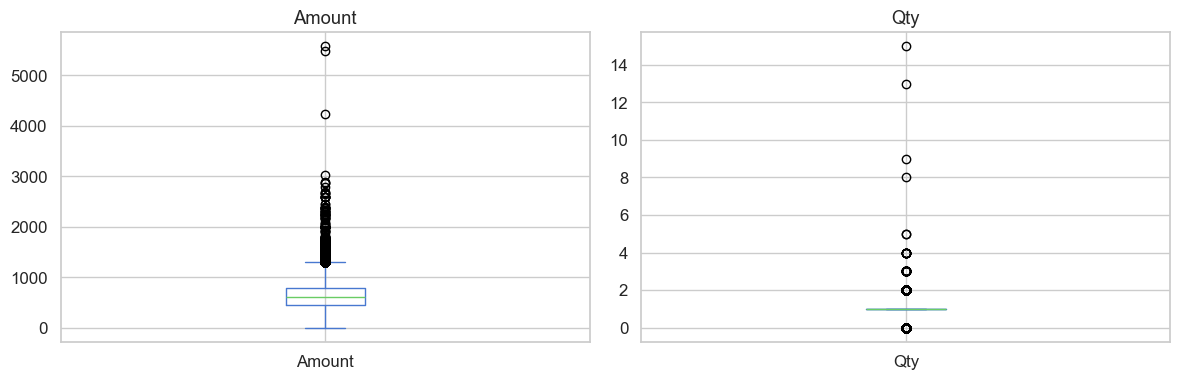

In [238]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
amazon_clean["Amount"].plot(kind="box", ax=axes[0], title="Amount")
amazon_clean["Qty"].plot(kind="box", ax=axes[1], title="Qty")
plt.tight_layout()

In [239]:
# Are there "Shipped" orders with no Amount?
shipped_no_amt = amazon_clean[
    amazon_clean["Status"].str.contains("Ship", na=False) & amazon_clean["Amount"].isnull()
]
print(f"Shipped orders with null Amount: {len(shipped_no_amt)}")

# Are there orders with Qty=0 but a positive Amount?
qty0_with_amt = amazon_clean[(amazon_clean["Qty"] == 0) & (amazon_clean["Amount"] > 0)]
print(f"Qty=0 rows with positive Amount: {len(qty0_with_amt)}")

# Amount summary per Status (last expr shown automatically)
amazon_clean.groupby("Status")["Amount"].agg(
    count="count", mean="mean", n_missing=lambda x: x.isnull().sum()
)

Shipped orders with null Amount: 227
Qty=0 rows with positive Amount: 5136


,count,mean,n_missing
Status,,,
Cancelled,10766,642.70,7563
Pending,656,655.90,2
Pending - Waiting for Pick Up,281,683.77,0
Shipped,77592,648.54,208
Shipped - Damaged,1,"1,136.00",0
Shipped - Delivered to Buyer,28761,648.48,8
Shipped - Lost in Transit,5,399.40,0
Shipped - Out for Delivery,35,770.60,0
Shipped - Picked Up,973,679.60,0


---
### Data Integrity Checks — Customer Sales & Product Catalog

The `describe()` output revealed two serious issues:
1. **`customer_raw`** — `DATE` column has top value `"MULBERRIES BOUTIQUE"` (a customer name!) and `CUSTOMER` has top value `"Feb-22"` (a month). This means some rows have **shifted/misaligned columns**.
2. **`catalog_raw`** — `SKU Code` top value is `"#REF!"` (Excel formula error leaked into the data).

In [240]:
# ── Investigate customer_raw column misalignment ──────────────────────────────
# A valid DATE looks like MM-DD-YY or MM-DD-YYYY. Find rows that don't match.
import re
date_pattern = r'^\d{1,2}[-/]\d{1,2}[-/]\d{2,4}$'

bad_date_mask = ~customer_raw['DATE'].fillna('').astype(str).str.match(date_pattern)
print(f"Rows where DATE is not a valid date format: {bad_date_mask.sum()}")
print(f"Sample bad DATE values:")
print(customer_raw.loc[bad_date_mask, 'DATE'].value_counts().head(10))

print("\n── Sample misaligned rows ──")
display(customer_raw[bad_date_mask].head(10))

Rows where DATE is not a valid date format: 18797
Sample bad DATE values:
DATE
MULBERRIES BOUTIQUE                   1904
COTTON CLOSET LTD                      659
VAHARSHA BOUTIQUE                      632
ETHNIC WEAVES FASHION LLC              556
RIVAAN LLC                             528
GALAXY GROUP OF COMPANIES PVT. LTD     452
THILAS BOMBAY BOUTIQUE SDN BHD         436
BHANU SALEINE NAUNITHAM                433
FUSION FASHIONS CORP.                  423
THANA MARIMUTHU                        419
Name: count, dtype: int64

── Sample misaligned rows ──


,index,DATE,Months,CUSTOMER,Style,SKU,Size,PCS,RATE,GROSS AMT
18635,18635,SKU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18636,18636,JNE3826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18637,18637,JNE3827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18638,18638,JNE3828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18639,18639,JNE3853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18640,18640,JNE3855,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18641,18641,JNE3858,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18642,18642,JNE3829,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18643,18643,JNE3830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18644,18644,JNE3849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [241]:
# ── Cross-check: do these bad rows ALSO have shifted Months/CUSTOMER? ──────────
# If DATE has a customer name AND CUSTOMER has a month → confirmed misalignment
month_pattern = r'^[A-Za-z]{3}-\d{2,4}$'   # e.g. "Feb-22"

if bad_date_mask.sum() > 0:
    sample = customer_raw[bad_date_mask].copy()
    sample['CUSTOMER_looks_like_month'] = sample['CUSTOMER'].astype(str).str.match(month_pattern)
    print(f"Of {len(sample)} bad-date rows, {sample['CUSTOMER_looks_like_month'].sum()} have a month in the CUSTOMER column")
    print("→ Confirms these rows are subtotal/header rows mixed into the data")

Of 18797 bad-date rows, 17756 have a month in the CUSTOMER column
→ Confirms these rows are subtotal/header rows mixed into the data


In [242]:
# ── Investigate catalog_raw Excel error leakage ────────────────────────────────
excel_errors = ['#REF!', '#N/A', '#VALUE!', '#NAME?', '#DIV/0!', '#NULL!', '#NUM!']

print("── Excel error values found in catalog_raw ──")
for col in catalog_raw.columns:
    col_str = catalog_raw[col].astype(str)
    for err in excel_errors:
        count = (col_str == err).sum()
        if count > 0:
            print(f"  {col:15s} → {count:3d} × '{err}'")

# View rows that have #REF! to see the rest of their content
ref_mask = catalog_raw.astype(str).apply(lambda r: r.isin(excel_errors).any(), axis=1)
print(f"\nTotal rows with ANY Excel error value: {ref_mask.sum()}")
display(catalog_raw[ref_mask].head(10))

── Excel error values found in catalog_raw ──
  SKU Code        →  15 × '#REF!'

Total rows with ANY Excel error value: 15


,index,SKU Code,Design No.,Stock,Category,Size,Color
65,65,#REF!,BL006,0.00,BLOUSE,FREE,Black
68,68,#REF!,BL008,0.00,BLOUSE,FREE,Red
73,73,#REF!,BL013,0.00,BLOUSE,FREE,Black
80,80,#REF!,BL019,0.00,BLOUSE,FREE,Pink
83,83,#REF!,BL021,0.00,BLOUSE,FREE,Black
84,84,#REF!,BL021,0.00,BLOUSE,FREE,Black
85,85,#REF!,BL021,1.00,BLOUSE,FREE,Black
86,86,#REF!,BL021,0.00,BLOUSE,FREE,Black
88,88,#REF!,BL022,0.00,BLOUSE,FREE,Beige
89,89,#REF!,BL022,0.00,BLOUSE,FREE,Beige


### Remediation
- **`customer_raw` misaligned rows** → drop them. They're aggregation/subtotal rows from the source Excel file and can't be repaired since the data is shifted across columns inconsistently.
- **`catalog_raw` Excel errors** → replace all `#REF!` / `#N/A` / etc. with `NaN` so they're treated as missing values, not legitimate strings.

In [243]:
# ── Fix customer_raw: drop misaligned rows ─────────────────────────────────────
customer_clean = customer_raw[~bad_date_mask].copy()
print(f"customer_raw: {len(customer_raw):,} → customer_clean: {len(customer_clean):,}  (dropped {bad_date_mask.sum():,} rows)")

# Verify DATE column is now consistent
print(f"\nUnique DATE values now: {customer_clean['DATE'].nunique()}")
print("Sample DATE values:", customer_clean['DATE'].dropna().unique()[:5].tolist())

customer_raw: 37,432 → customer_clean: 18,635  (dropped 18,797 rows)

Unique DATE values now: 162
Sample DATE values: ['06-05-21', '06-08-21', '06-11-21', '06-15-21', '06-17-21']


In [244]:
# ── Fix catalog_raw: replace Excel error values with NaN ───────────────────────
catalog_clean = catalog_raw.replace(excel_errors, np.nan).copy()

# Confirm the errors are gone
remaining = catalog_clean.astype(str).apply(lambda r: r.isin(excel_errors).any(), axis=1).sum()
print(f"Excel error values remaining: {remaining}")

# Show updated missing-value report
_ = check_missing(catalog_clean, "Product Catalog (cleaned)")

Excel error values remaining: 0

── Product Catalog (cleaned) ──


,missing,percent
SKU Code,98,1.06
Category,45,0.49
Color,45,0.49
Design No.,36,0.39
Stock,36,0.39
Size,36,0.39


## Phase 3 — Data Cleaning
> Apply every fix identified in Phase 2 so amazon_clean, customer_clean, catalog_clean are analysis-ready.

In [245]:
amazon_clean["Date"] = pd.to_datetime(amazon_clean["Date"], format="%m-%d-%y", errors="coerce")
customer_clean["DATE"] = pd.to_datetime(customer_clean["DATE"], format="%m-%d-%y", errors="coerce")

print("Amazon date range :", amazon_clean["Date"].min(), "→", amazon_clean["Date"].max())
print("Customer date range:", customer_clean["DATE"].min(), "→", customer_clean["DATE"].max())
print("Unparseable amazon dates :", amazon_clean["Date"].isna().sum())
print("Unparseable customer dates:", customer_clean["DATE"].isna().sum())

Amazon date range : 2022-03-31 00:00:00 → 2022-06-29 00:00:00
Customer date range: 2021-06-05 00:00:00 → 2022-05-11 00:00:00
Unparseable amazon dates : 0
Unparseable customer dates: 0


In [246]:
for col in ["PCS", "RATE", "GROSS AMT"]:
    customer_clean[col] = pd.to_numeric(customer_clean[col], errors="coerce")

mismatch = (customer_clean["PCS"] * customer_clean["RATE"] - customer_clean["GROSS AMT"]).abs()
print(f"Rows where PCS*RATE differs from GROSS AMT by >1: {(mismatch > 1).sum()}")
customer_clean[["PCS", "RATE", "GROSS AMT"]].describe()

Rows where PCS*RATE differs from GROSS AMT by >1: 7720


,PCS,RATE,GROSS AMT
count,"18,635.00","18,635.00","18,635.00"
mean,1.29,697.80,846.16
std,0.96,313.73,611.15
min,1.00,231.25,227.00
25%,1.00,462.50,475.00
50%,1.00,599.00,664.00
75%,1.00,850.00,975.00
max,15.00,"2,087.50","9,745.00"


In [247]:
# Normalize text fields
amazon_clean["Category"] = amazon_clean["Category"].replace({"kurta": "Kurta"})
amazon_clean["ship-city"]  = amazon_clean["ship-city"].str.strip().str.title()
amazon_clean["ship-state"] = amazon_clean["ship-state"].str.strip().str.title()
customer_clean["CUSTOMER"] = customer_clean["CUSTOMER"].str.strip().str.title()

In [248]:
# Handle cancelled/null-Amount rows
mask = amazon_clean["Status"].str.contains("Cancel", na=False) & amazon_clean["Amount"].isna()
amazon_clean.loc[mask, "Amount"] = 0
print(f"Set Amount=0 for {mask.sum()} cancelled rows")
print("Remaining null Amounts:", amazon_clean["Amount"].isna().sum())

Set Amount=0 for 7563 cancelled rows
Remaining null Amounts: 229


In [249]:
# Investigating remaining null Amounts
remaining = amazon_clean[amazon_clean["Amount"].isna()]
print(f"Remaining null Amount rows: {len(remaining)}")
remaining["Status"].value_counts()

Remaining null Amount rows: 229


Status
Shipped                         208
Shipped - Delivered to Buyer      8
Shipping                          8
Shipped - Returned to Seller      3
Pending                           2
Name: count, dtype: int64

In [250]:
# Checking if there's a pattern for null Amount in courier status
amazon_clean.loc[amazon_clean["Amount"].isna(), "Courier Status"].value_counts(dropna=False)

Courier Status
Unshipped    123
Cancelled     95
NaN           11
Name: count, dtype: int64

Since the unique values are just `Unshipped`, `Cancelled`, and `NaN`, it's safe to set `Amount=0` since they're not missing a price.

In [251]:
mask = amazon_clean["Amount"].isna()
print(f"Setting Amount=0 for {mask.sum()} remaining unshipped/cancelled rows")
amazon_clean.loc[mask, "Amount"] = 0
print("Null Amounts remaining:", amazon_clean["Amount"].isna().sum())

Setting Amount=0 for 229 remaining unshipped/cancelled rows
Null Amounts remaining: 0


In [252]:
# Verify the Amount fix worked
print(f"Null Amount rows now:        {amazon_clean['Amount'].isna().sum()}")
print(f"Amount==0 rows now:          {(amazon_clean['Amount'] == 0).sum()}")
print("\nStatus breakdown of Amount==0 rows (should be cancellations / unshipped):")
amazon_clean.loc[amazon_clean['Amount'] == 0, 'Status'].value_counts()

Null Amount rows now:        0
Amount==0 rows now:          10135

Status breakdown of Amount==0 rows (should be cancellations / unshipped):


Status
Cancelled                        7563
Shipped                          1726
Shipped - Delivered to Buyer      724
Shipped - Returned to Seller       54
Shipped - Picked Up                28
Pending                            19
Pending - Waiting for Pick Up       9
Shipping                            8
Shipped - Lost in Transit           2
Shipped - Returning to Seller       2
Name: count, dtype: int64

In [253]:
# Drop unnecessary columns
amazon_clean = amazon_clean.drop(columns=["promotion-ids", "fulfilled-by"], errors="ignore")

In [254]:
# Normalize SKU join keys (recovers any case/whitespace-only mismatches)
amazon_clean["SKU"]       = amazon_clean["SKU"].str.strip().str.upper()
catalog_clean["SKU Code"] = catalog_clean["SKU Code"].str.strip().str.upper()

In [255]:
# Reconcile join keys
amazon_skus  = set(amazon_clean["SKU"].dropna().unique())
catalog_skus = set(catalog_clean["SKU Code"].dropna().unique())
print(f"Amazon SKUs : {len(amazon_skus):,}")
print(f"Catalog SKUs: {len(catalog_skus):,}")
print(f"In both     : {len(amazon_skus & catalog_skus):,}")
print(f"Amazon-only : {len(amazon_skus - catalog_skus):,}")

Amazon SKUs : 7,195
Catalog SKUs: 9,169
In both     : 6,618
Amazon-only : 577


In [256]:
unmatched_mask = ~amazon_clean["SKU"].isin(catalog_skus)
unmatched_rev = amazon_clean.loc[unmatched_mask, "Amount"].sum()
total_rev = amazon_clean["Amount"].sum()
print(f"Unmatched SKUs: {unmatched_mask.sum():,} rows, "
      f"₹{unmatched_rev:,.0f} ({unmatched_rev/total_rev:.1%} of revenue)")

Unmatched SKUs: 7,704 rows, ₹4,121,807 (5.2% of revenue)


In [257]:
for name, df in [("amazon_clean", amazon_clean),
                 ("customer_clean", customer_clean),
                 ("catalog_clean", catalog_clean)]:
    print(f"{name:16s} {df.shape[0]:>7,} rows × {df.shape[1]:>2} cols   "
          f"nulls={df.isna().sum().sum():,}")

amazon_clean     128,968 rows × 20 cols   nulls=14,796
customer_clean    18,635 rows × 10 cols   nulls=1,417
catalog_clean      9,271 rows ×  7 cols   nulls=296


---
## Phase 4 — Feature Engineering
> Derive time, revenue, and status features. Build the customer-level RFM table.

In [258]:
# Step 2 — Time features
amazon_clean["order_month"] = amazon_clean["Date"].dt.to_period("M").astype(str)
amazon_clean["order_dow"]   = amazon_clean["Date"].dt.day_name()

customer_clean["order_month"] = customer_clean["DATE"].dt.to_period("M").astype(str)
customer_clean["order_dow"]   = customer_clean["DATE"].dt.day_name()

amazon_clean[["Date", "order_month", "order_dow"]].head()

,Date,order_month,order_dow
0,2022-04-30,2022-04,Saturday
1,2022-04-30,2022-04,Saturday
2,2022-04-30,2022-04,Saturday
3,2022-04-30,2022-04,Saturday
4,2022-04-30,2022-04,Saturday


In [259]:
# Step 3 — Status flags on Amazon
s = amazon_clean["Status"].fillna("")
amazon_clean["is_cancelled"] = s.str.contains("Cancel", case=False)
amazon_clean["is_returned"]  = s.str.contains("Return|Rejected|Lost|Damaged", case=False, regex=True)
amazon_clean["is_shipped"]   = s.str.contains("Ship", case=False) & ~amazon_clean["is_returned"]

amazon_clean[["is_cancelled", "is_returned", "is_shipped"]].sum()

is_cancelled     18329
is_returned       2115
is_shipped      107585
dtype: int64

In [260]:
# Step 4 — Revenue column
amazon_clean["revenue"] = amazon_clean["Amount"]
print(f"Total Amazon revenue:               ₹{amazon_clean['revenue'].sum():,.0f}")
print(f"Revenue from non-cancelled only:    ₹{amazon_clean.loc[~amazon_clean['is_cancelled'], 'revenue'].sum():,.0f}")

Total Amazon revenue:               ₹78,589,556
Revenue from non-cancelled only:    ₹71,670,272


In [261]:
# Step 5 — Snapshot date for RFM recency
SNAPSHOT_DATE = customer_clean["DATE"].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {SNAPSHOT_DATE.date()}")

Snapshot date: 2022-05-12


In [262]:
# Step 6 — Build the RFM table
rfm = (
    customer_clean
    .dropna(subset=["CUSTOMER", "DATE", "GROSS AMT"])
    .groupby("CUSTOMER")
    .agg(
        recency   =("DATE",      lambda x: (SNAPSHOT_DATE - x.max()).days),
        frequency =("DATE",      "nunique"),
        monetary  =("GROSS AMT", "sum"),
    )
    .reset_index()
)

print(f"RFM table: {rfm.shape[0]:,} customers")
rfm.describe()

RFM table: 149 customers


,recency,frequency,monetary
count,149.00,149.00,149.00
mean,132.54,1.79,"105,826.59"
std,103.20,1.71,"206,900.08"
min,1.00,1.00,"5,058.00"
25%,45.00,1.00,"21,126.00"
50%,96.00,1.00,"45,974.00"
75%,219.00,2.00,"112,063.00"
max,338.00,11.00,"2,094,070.50"


In [263]:
# Step 7 — RFM scoring (1–5 quintiles)
rfm["R_score"] = pd.qcut(rfm["recency"], 5, labels=[5,4,3,2,1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5]).astype(int)
rfm["RFM_score"] = rfm["R_score"]*100 + rfm["F_score"]*10 + rfm["M_score"]

rfm.head()

,CUSTOMER,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,Aanchol,300,1,"11,452.00",1,1,1,111
1,Abbi Collection,96,1,"37,114.00",3,1,3,313
2,Abdul Rahman(Singapore),147,2,"48,106.00",2,4,3,243
3,Addven Solutions Private Limited,204,1,"32,228.00",2,1,3,213
4,Ajs Indian Boutique,24,1,"8,368.75",5,1,1,511


In [264]:
# Step 8 — Customer segments
def segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]

    # — Recent (R >= 4) —
    if r >= 4 and f >= 4 and m >= 4:  return "Champions"
    if r >= 4 and f >= 3:              return "Loyal"
    if r >= 4 and m >= 4:              return "Big Spenders"
    if r >= 4:                         return "New / Recent"

    # — Mid (R == 3) —
    if r == 3 and f >= 3:              return "Potential Loyalists"
    if r == 3:                         return "Needs Attention"

    # — Lapsed (R <= 2) —
    if r <= 2 and (f >= 3 or m >= 4):  return "At Risk"
    if r <= 2 and f >= 2:              return "Hibernating"
    return "Lost"

rfm["segment"] = rfm.apply(segment, axis=1)
rfm["segment"].value_counts()

segment
At Risk                40
Loyal                  22
Champions              21
Potential Loyalists    15
Needs Attention        13
Hibernating            12
New / Recent           11
Lost                    8
Big Spenders            7
Name: count, dtype: int64

In [265]:
# Step 9 — Final sanity check
print("Final feature-engineered tables:")
for name, df in [("amazon_clean",   amazon_clean),
                 ("customer_clean", customer_clean),
                 ("rfm",            rfm)]:
    print(f"  {name:16s} {df.shape[0]:>7,} × {df.shape[1]:>2}")

Final feature-engineered tables:
  amazon_clean     128,968 × 26
  customer_clean    18,635 × 12
  rfm                  149 ×  9


---
## Phase 5 — Univariate Analysis
> Examine the distribution of each key variable on its own. Goal: spot skew, dominant categories, and time patterns that should shape the dashboard.

For each variable we ask three questions:
1. **What's the shape?** Symmetric, skewed, bimodal?
2. **Where is the mass?** A few categories carrying most of the volume, or evenly spread?
3. **What's the headline metric?** Mean vs median — pick the one that survives the long tail.

### Step 2 — Revenue per order
Revenue distributions in e-commerce are almost always right-skewed: most orders cluster at low values, a few drive disproportionate revenue.
We plot it twice — raw, and log-y restricted to non-zero — because the cancelled-order spike at ₹0 dominates the raw view.

Mean revenue:   ₹609
Median revenue: ₹583


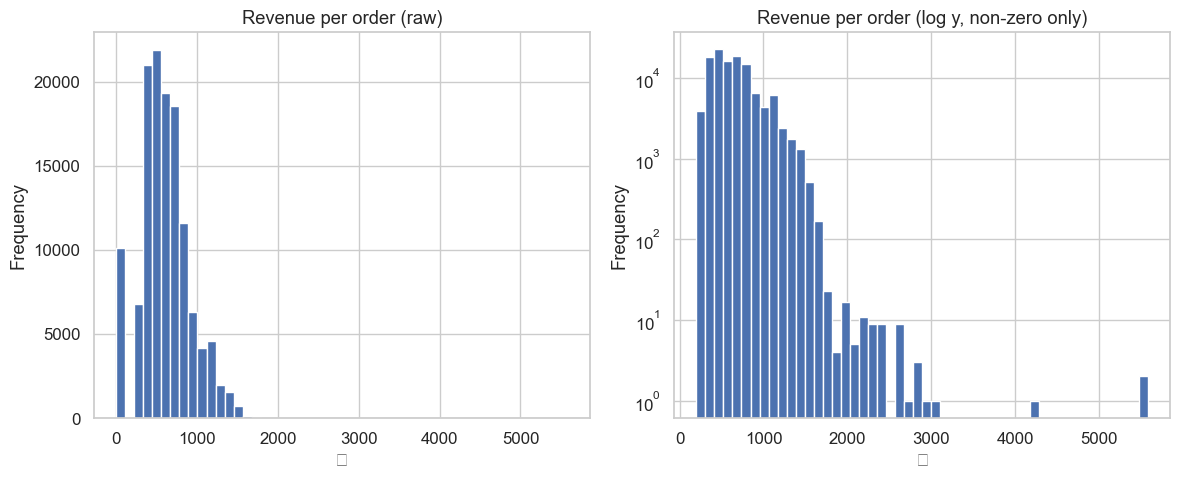

In [266]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
amazon_clean["revenue"].plot(kind="hist", bins=50, ax=axes[0], color=COLOR_PRIMARY)
axes[0].set_title("Revenue per order (raw)")
axes[0].set_xlabel("₹")

amazon_clean.loc[amazon_clean["revenue"] > 0, "revenue"].plot(
    kind="hist", bins=50, ax=axes[1], color=COLOR_PRIMARY, logy=True
)
axes[1].set_title("Revenue per order (log y, non-zero only)")
axes[1].set_xlabel("₹")
plt.tight_layout()

print(f"Mean revenue:   ₹{amazon_clean['revenue'].mean():,.0f}")
print(f"Median revenue: ₹{amazon_clean['revenue'].median():,.0f}")

**Interpretation**
- Expect the **median to be meaningfully lower than the mean** — that's the long tail at work.
- The dashboard's headline "typical order value" should be the **median** (or trimmed mean); mean would be inflated by a handful of high-value B2B / multi-item orders.
- The log plot reveals the tail's actual extent; if it stretches past ₹3,000 with real density, those orders deserve their own segment view.

### Step 3 — Orders per month
Line-item count by month. Note this counts *every* line (including cancelled), so it's a volume measure, not a revenue measure.

order_month
2022-03      171
2022-04    49065
2022-05    42036
2022-06    37696
dtype: int64


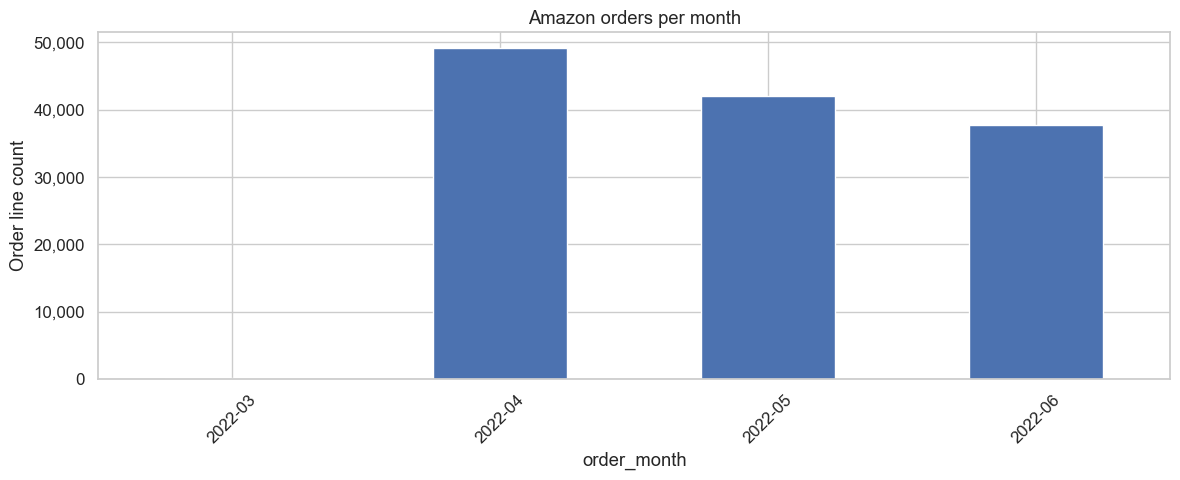

In [267]:
monthly = amazon_clean.groupby("order_month").size()
ax = monthly.plot(kind="bar", figsize=FIGSIZE, color=COLOR_PRIMARY)
ax.set_title("Amazon orders per month")
ax.set_ylabel("Order line count")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()

print(monthly)

**Interpretation**
- The dataset spans roughly **Apr–Jun 2022**. If one bar is dramatically shorter, check whether it's a partial month (data export cutoff) before claiming a real dip.
- Order count alone doesn't tell you whether the business is growing — pair it with the revenue chart below.

### Step 4 — Revenue per month (non-cancelled)
Same axis but using `revenue` and excluding cancelled rows. This is what would appear on the executive dashboard.

order_month
2022-03        ₹94,810
2022-04    ₹26,234,520
2022-05    ₹23,951,575
2022-06    ₹21,389,367
Name: revenue, dtype: str


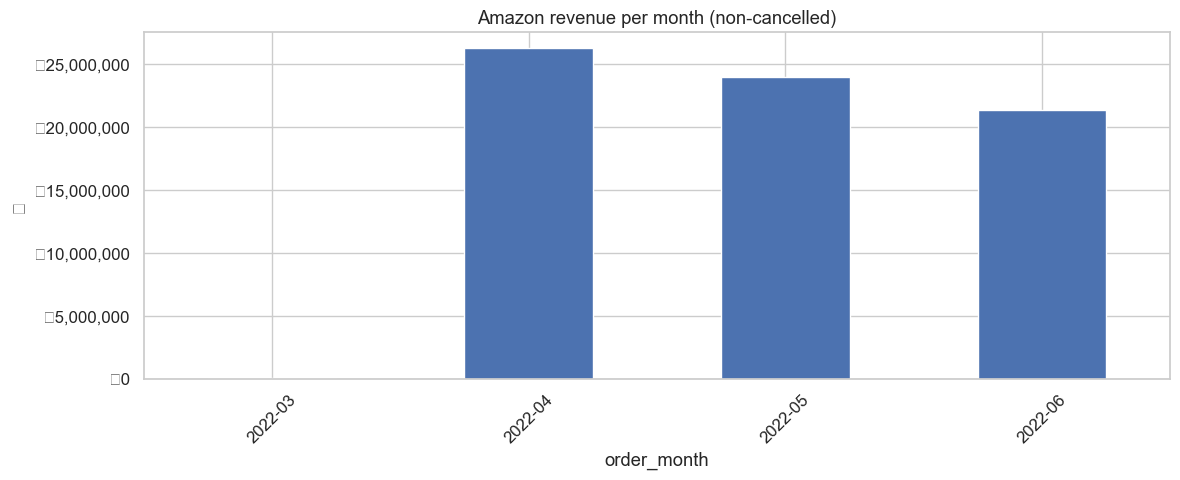

In [268]:
rev_monthly = (
    amazon_clean.loc[~amazon_clean["is_cancelled"]]
    .groupby("order_month")["revenue"].sum()
)
ax = rev_monthly.plot(kind="bar", figsize=FIGSIZE, color=COLOR_PRIMARY)
ax.set_title("Amazon revenue per month (non-cancelled)")
ax.set_ylabel("₹")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("₹{x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()

print(rev_monthly.apply(lambda x: f"₹{x:,.0f}"))

**Interpretation**
- Compare this shape to Step 3. If order-count and revenue trends **diverge** (count up, revenue flat), it means **average order value is falling** — typically a discounting or product-mix issue.
- If they **track together**, growth/decline is purely volume-driven.

### Step 5 — Category mix
Which product categories are doing the volume? Sorted descending so the leaders are obvious.

Top 3 categories account for 90% of orders


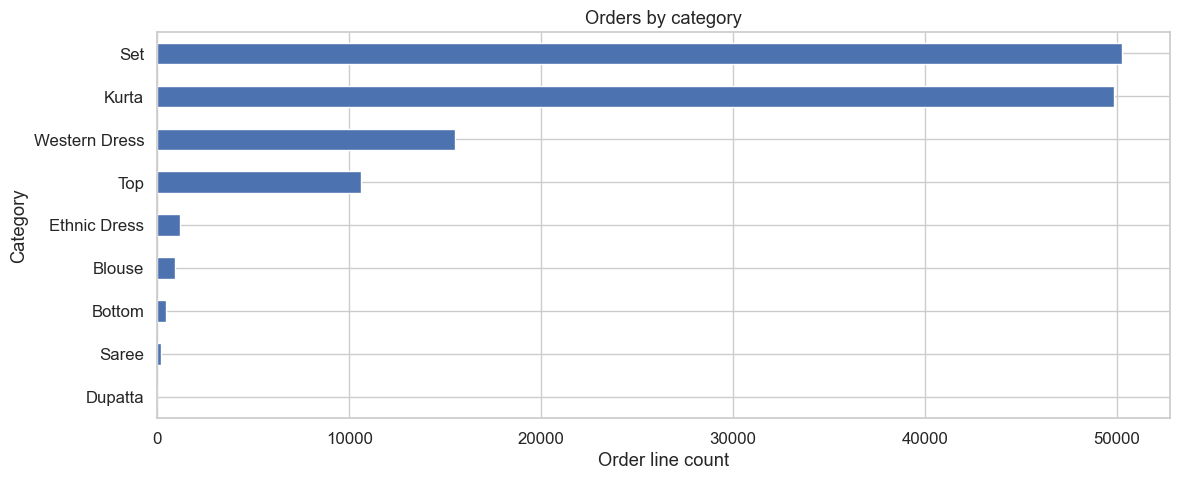

In [269]:
cat_counts = amazon_clean["Category"].value_counts()
ax = cat_counts.plot(kind="barh", figsize=FIGSIZE, color=COLOR_PRIMARY)
ax.set_title("Orders by category")
ax.set_xlabel("Order line count")
ax.invert_yaxis()
plt.tight_layout()

top3_share = cat_counts.head(3).sum() / cat_counts.sum()
print(f"Top 3 categories account for {top3_share:.0%} of orders")

**Interpretation**
- E-commerce category distributions usually follow the **80/20 rule** — expect 2–3 categories to dominate.
- Categories below ~1% of volume (e.g. Dupatta with single-digit counts) are statistical noise and should be **grouped into "Other"** in the dashboard to avoid cluttering charts.
- If the top category is also the highest-revenue category, the business is **focused**. If volume leader ≠ revenue leader, you have a pricing/mix story worth surfacing.

### Step 6 — Size distribution
Reindexed to the natural progression XS → 6XL so trends are readable. Alphabetical order would put "3XL" before "L".

Size
XS      11161
S       17090
M       22709
L       22129
XL      20875
XXL     18096
3XL     14815
4XL       427
5XL       550
6XL       738
Free      378
Name: count, dtype: int64


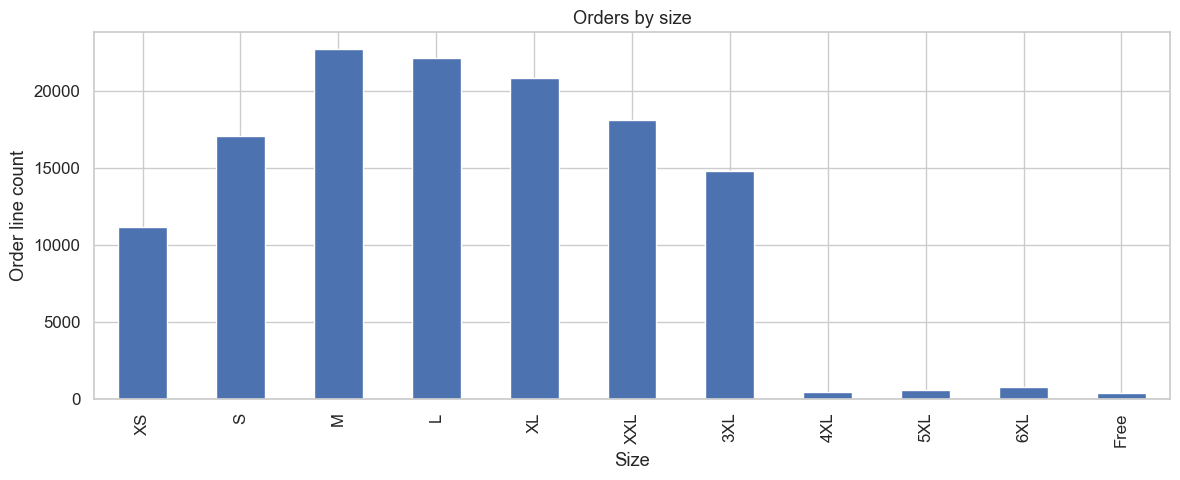

In [270]:
size_order = ["XS", "S", "M", "L", "XL", "XXL", "3XL", "4XL", "5XL", "6XL", "Free"]
counts = amazon_clean["Size"].value_counts().reindex(size_order).dropna()
ax = counts.plot(kind="bar", figsize=FIGSIZE, color=COLOR_PRIMARY)
ax.set_title("Orders by size")
ax.set_ylabel("Order line count")
plt.tight_layout()

print(counts)

**Interpretation**
- A healthy distribution **peaks around M/L** and tapers symmetrically — that's the typical body-size curve.
- If the curve is **skewed toward larger sizes**, the business may be under-stocking smaller sizes (lost sales) or over-promoting plus ranges.
- "Free" size is one-size-fits-all (dupattas, scarves) — its share tells you the accessory-vs-apparel split.

### Step 7 — Order status mix
Two views side-by-side: raw 13-category Status for granularity, and the 3 collapsed flags for the dashboard view.

Cancellation rate: 14.2%
Return rate:       1.6%


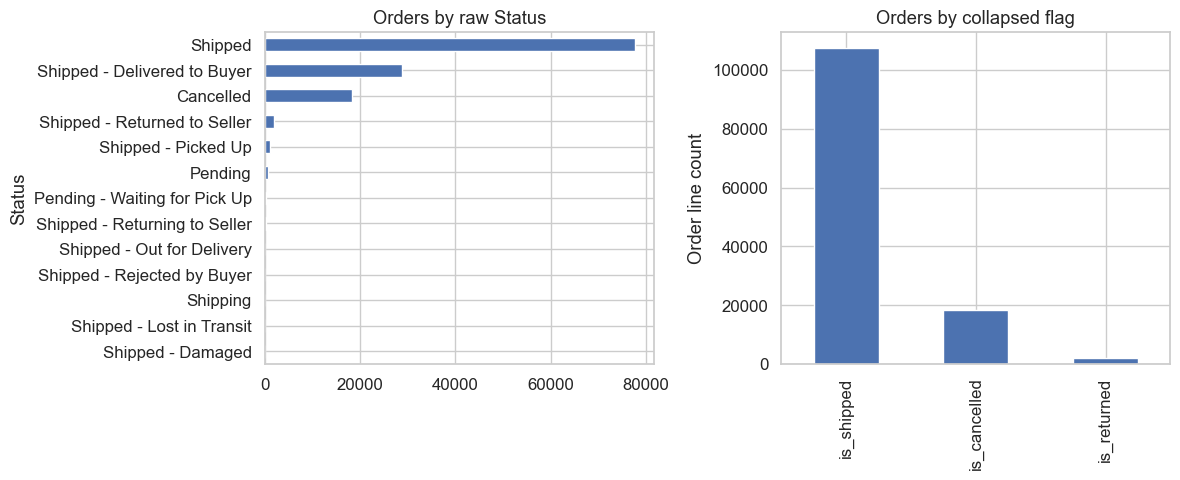

In [271]:
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)

amazon_clean["Status"].value_counts().plot(kind="barh", ax=axes[0], color=COLOR_PRIMARY)
axes[0].set_title("Orders by raw Status")
axes[0].invert_yaxis()

flag_counts = amazon_clean[["is_shipped", "is_cancelled", "is_returned"]].sum()
flag_counts.plot(kind="bar", ax=axes[1], color=COLOR_PRIMARY)
axes[1].set_title("Orders by collapsed flag")
axes[1].set_ylabel("Order line count")

plt.tight_layout()

cancel_rate = amazon_clean["is_cancelled"].mean()
return_rate = amazon_clean["is_returned"].mean()
print(f"Cancellation rate: {cancel_rate:.1%}")
print(f"Return rate:       {return_rate:.1%}")

**Interpretation**
- **Cancellation rate** is the headline operations metric. Anything **>10%** is high enough to warrant investigation — often a stock or pricing issue.
- **Return rate** in apparel is normally 5–15%; if it's higher, sizing/quality is suspect.
- The raw view reveals process states ("Pending - Waiting for Pick Up", "Shipped - Returning to Seller") that the collapsed flags hide — useful when diagnosing *why* an order ended where it did.

### Step 8 — RFM component distributions
Before scoring, look at the raw R/F/M variables. Each one has a typical shape, and deviations are diagnostic.

One-time buyers (frequency=1): 69%
Median recency: 96 days
Median monetary: ₹45,974


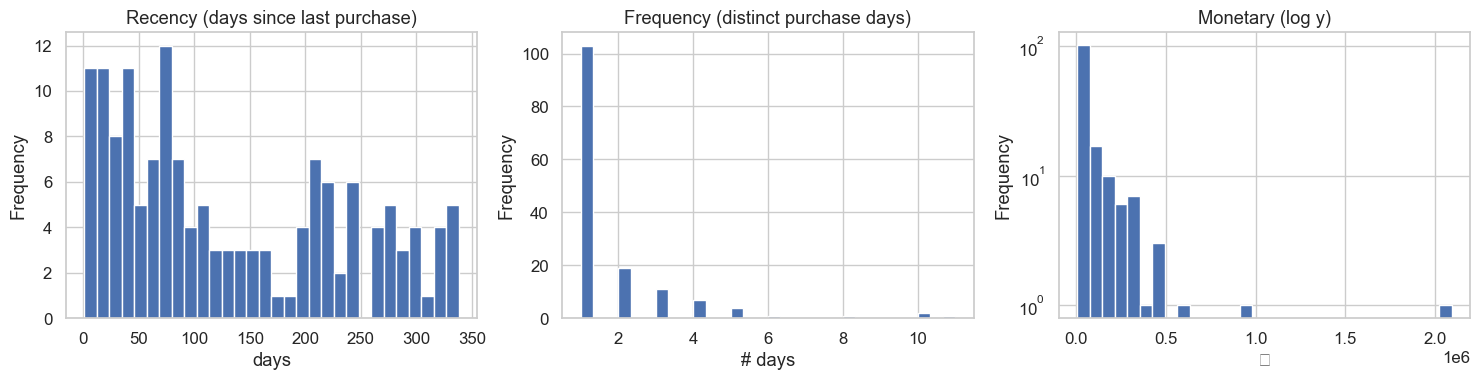

In [272]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
rfm["recency"].plot(kind="hist", bins=30, ax=axes[0], color=COLOR_PRIMARY)
axes[0].set_title("Recency (days since last purchase)")
axes[0].set_xlabel("days")

rfm["frequency"].plot(kind="hist", bins=30, ax=axes[1], color=COLOR_PRIMARY)
axes[1].set_title("Frequency (distinct purchase days)")
axes[1].set_xlabel("# days")

rfm.loc[rfm["monetary"] > 0, "monetary"].plot(kind="hist", bins=30, ax=axes[2], color=COLOR_PRIMARY, logy=True)
axes[2].set_title("Monetary (log y)")
axes[2].set_xlabel("₹")

plt.tight_layout()

print(f"One-time buyers (frequency=1): {(rfm['frequency'] == 1).mean():.0%}")
print(f"Median recency: {rfm['recency'].median():.0f} days")
print(f"Median monetary: ₹{rfm['monetary'].median():,.0f}")

**Interpretation**
- **Recency** typically has two modes: a recent-buyer cluster (last 30–60 days) and a lapsed cluster (180+ days). A flat distribution = even churn over time.
- **Frequency** is usually heavily right-skewed — most customers buy once. If >70% have frequency=1, retention is the business problem, not acquisition.
- **Monetary** is plotted log-y to compress the long tail. A handful of high-monetary customers in the right tail are the **VIPs** the dashboard should call out separately.

### Step 9 — Segment counts
The named segments derived from the R/F/M scores. This is the slide-ready customer breakdown.

segment
At Risk                26.8%
Loyal                  14.8%
Champions              14.1%
Potential Loyalists    10.1%
Needs Attention         8.7%
Hibernating             8.1%
New / Recent            7.4%
Lost                    5.4%
Big Spenders            4.7%
Name: count, dtype: str


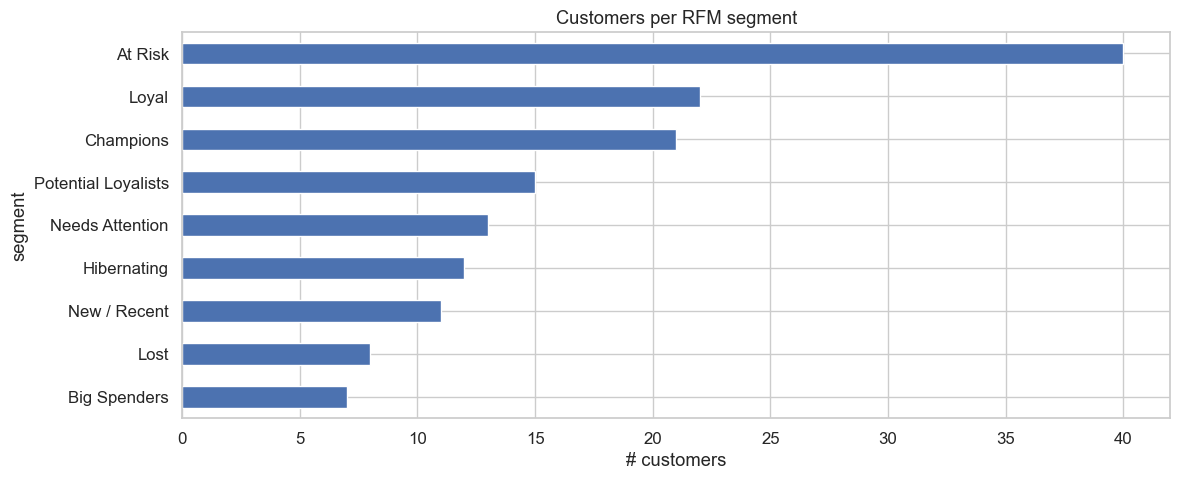

In [273]:
seg_counts = rfm["segment"].value_counts()
ax = seg_counts.plot(kind="barh", figsize=FIGSIZE, color=COLOR_PRIMARY)
ax.set_title("Customers per RFM segment")
ax.set_xlabel("# customers")
ax.invert_yaxis()
plt.tight_layout()

print((seg_counts / seg_counts.sum() * 100).round(1).astype(str) + "%")

**Interpretation**
With the tightened 9-segment scheme, every customer now has a diagnosis instead of being dumped in "Others". Read the bars in **three bands**:

- **Recent band (Champions / Loyal / Big Spenders / New)** — the active customer base. These four together should make up your *current* revenue. If they're a thin slice, the business is running on lapsed customers and is fragile.
- **Mid band (Potential Loyalists / Needs Attention)** — the **retention battleground**. These customers are cooling but not gone. Marketing actions here have the highest ROI.
- **Lapsed band (At Risk / Hibernating / Lost)** — already gone or going. **"At Risk"** is the win-back budget target (lapsed *but were valuable*). **"Lost"** is usually the largest bucket in real datasets; if it's >40% the dashboard's headline story is churn.

➡ Phase 6 will cross these segments with categories, geography, and time to reveal *why* customers fall where they do.

---
## Phase 6 — Bivariate & Segment Analysis
> Now cross variables to find the *stories* a single-variable view misses. Each chart pairs one dimension (category, geography, time, segment) with one outcome (revenue, cancellation rate, AOV).

Reading bivariate charts: look for **disagreement between count and value** (volume ≠ revenue), **concentration** (one bar dwarfing the rest), and **outliers** (one category behaving unlike the others).

### Step 1 — Revenue vs order count by category
Phase 5 showed *which categories sell most*. Now we ask: do those same categories *generate the most revenue*, or is a smaller category punching above its weight?

               orders       revenue    aov
Category                                  
Set             42945 35,729,571.00 832.00
Kurta           42620 19,424,850.00 456.00
Western Dress   13378 10,209,590.00 763.00
Top              9346  4,904,066.00 525.00
Ethnic Dress     1014    732,744.00 723.00
Blouse            810    418,389.00 517.00
Bottom            380    135,453.00 356.00
Saree             143    114,694.00 802.00
Dupatta             3        915.00 305.00


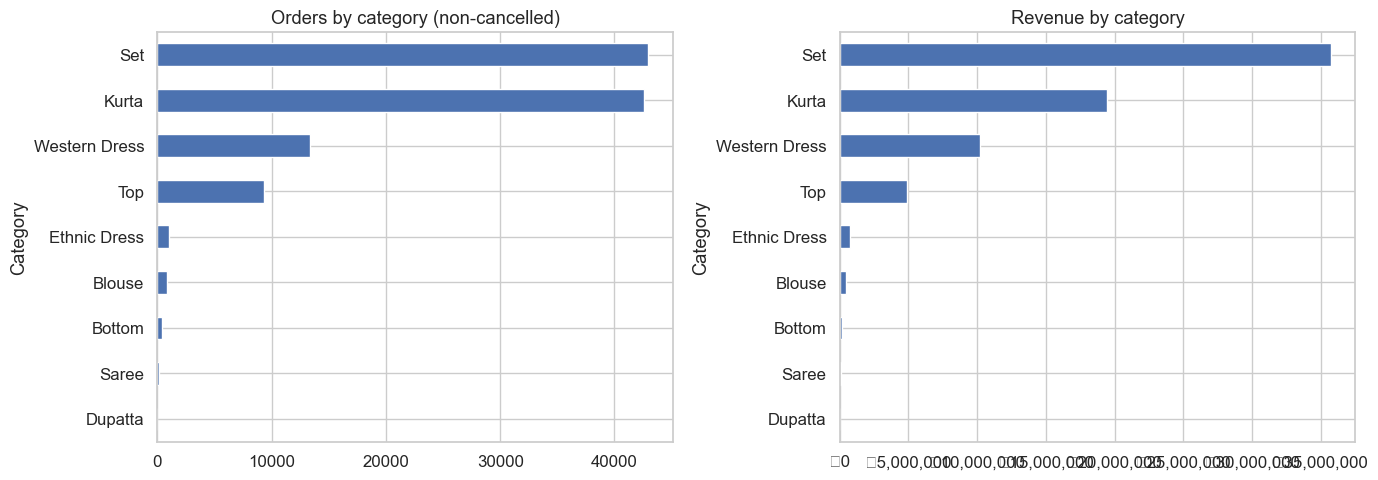

In [274]:
cat_summary = (
    amazon_clean.loc[~amazon_clean["is_cancelled"]]
    .groupby("Category")
    .agg(orders=("Order ID", "count"),
         revenue=("revenue", "sum"),
         aov=("revenue", "mean"))
    .sort_values("revenue", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_summary["orders"].plot(kind="barh", ax=axes[0], color=COLOR_PRIMARY)
axes[0].set_title("Orders by category (non-cancelled)")
axes[0].invert_yaxis()

cat_summary["revenue"].plot(kind="barh", ax=axes[1], color=COLOR_PRIMARY)
axes[1].set_title("Revenue by category")
axes[1].xaxis.set_major_formatter(mticker.StrMethodFormatter("₹{x:,.0f}"))
axes[1].invert_yaxis()
plt.tight_layout()

print(cat_summary.assign(aov=lambda d: d["aov"].round(0)))

**Interpretation**
- If the two bar charts have the **same order**, volume drives revenue — the business is undifferentiated by price.
- If a category climbs in the revenue chart (e.g. **Western Dress** higher than its order rank suggests), it has a **higher AOV** — premium product, worth a dashboard callout.
- A category that *falls* in the revenue chart is a **low-AOV volume play** (often kurta/top basics). Margin matters more than headline revenue here.

### Step 2 — Cancellation rate by category
Volume tells you what's selling. Cancellation rate tells you what's *breaking*. A high-volume category with a high cancel rate is operationally expensive.

               orders cancel_rate
Category                         
Set             50281       14.6%
Kurta           49873       14.5%
Western Dress   15500       13.7%
Bottom            440       13.6%
Saree             164       12.8%
Blouse            926       12.5%
Ethnic Dress     1159       12.5%
Top             10622       12.0%
Dupatta             3        0.0%


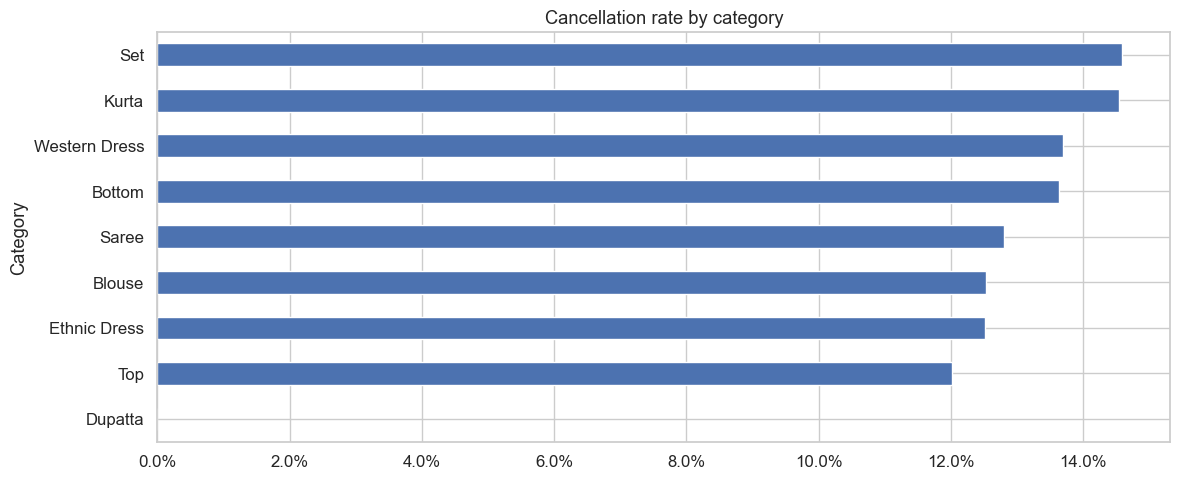

In [275]:
cancel_by_cat = (
    amazon_clean.groupby("Category")
    .agg(orders=("Order ID", "count"),
         cancel_rate=("is_cancelled", "mean"))
    .sort_values("cancel_rate", ascending=False)
)

ax = cancel_by_cat["cancel_rate"].plot(kind="barh", figsize=FIGSIZE, color=COLOR_PRIMARY)
ax.set_title("Cancellation rate by category")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.invert_yaxis()
plt.tight_layout()

print(cancel_by_cat.assign(cancel_rate=lambda d: (d['cancel_rate']*100).round(1).astype(str) + '%'))

**Interpretation**
- A baseline cancel rate of ~14% (the dataset-wide average) is the comparison line. Categories visibly above it have a problem; below it are operating cleanly.
- **Tiny-N categories** (Dupatta, Saree with single-digit counts) will swing wildly — ignore unless they grow.
- **High-volume + high-cancel-rate** is the worst combo: investigate stock levels, pricing, or listing accuracy for those SKUs.

### Step 3 — Revenue by state (top 15)
Where is the money coming from? E-commerce is usually concentrated in 3–5 metro states.

Top 5 states drive 56% of revenue


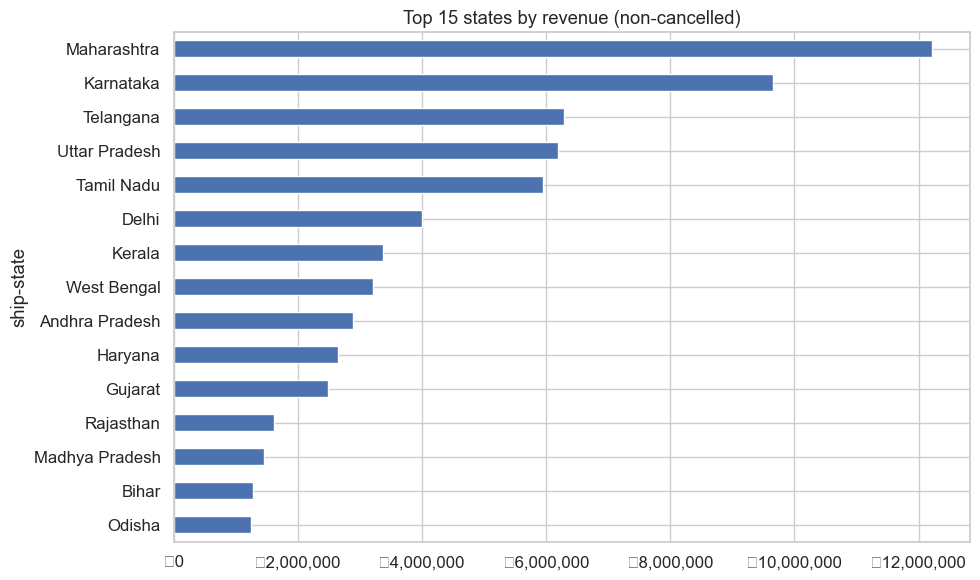

In [276]:
state_rev = (
    amazon_clean.loc[~amazon_clean["is_cancelled"]]
    .groupby("ship-state")["revenue"].sum()
    .sort_values(ascending=False)
    .head(15)
)

ax = state_rev.plot(kind="barh", figsize=(10, 6), color=COLOR_PRIMARY)
ax.set_title("Top 15 states by revenue (non-cancelled)")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("₹{x:,.0f}"))
ax.invert_yaxis()
plt.tight_layout()

top5_share = state_rev.head(5).sum() / amazon_clean.loc[~amazon_clean["is_cancelled"], "revenue"].sum()
print(f"Top 5 states drive {top5_share:.0%} of revenue")

**Interpretation**
- Expect **Maharashtra, Karnataka, Tamil Nadu, Telangana, Delhi** to lead — the metro/IT-hub cluster.
- If top 5 states drive **>60%** of revenue, the business is geographically concentrated. Growth strategy = either deepen those markets or invest in Tier-2 expansion.
- A low-revenue but high-volume state suggests **smaller-ticket buyers** — a different demographic worth its own dashboard filter.

### Step 4 — Monthly revenue by top categories
Are top categories all growing/declining together, or is there churn within the mix?

Category          Kurta          Set         Top Western Dress
order_month                                                   
2022-03         ₹33,008      ₹51,532      ₹4,511        ₹5,479
2022-04      ₹7,239,538  ₹14,124,033  ₹1,672,892    ₹2,683,186
2022-05      ₹6,120,627  ₹11,527,284  ₹1,837,175    ₹3,970,177
2022-06      ₹6,031,677  ₹10,026,722  ₹1,389,488    ₹3,550,748


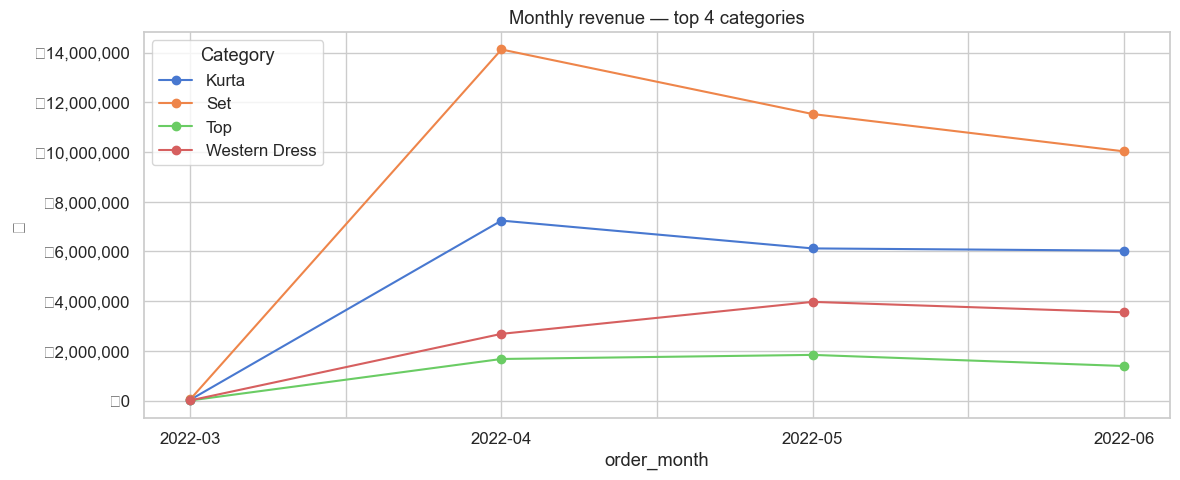

In [277]:
top_cats = cat_summary.head(4).index.tolist()
trend = (
    amazon_clean.loc[~amazon_clean["is_cancelled"] & amazon_clean["Category"].isin(top_cats)]
    .groupby(["order_month", "Category"])["revenue"].sum()
    .unstack(fill_value=0)
)

ax = trend.plot(kind="line", marker="o", figsize=FIGSIZE)
ax.set_title("Monthly revenue — top 4 categories")
ax.set_ylabel("₹")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("₹{x:,.0f}"))
plt.tight_layout()

print(trend.apply(lambda c: c.map(lambda x: f"₹{x:,.0f}")))

**Interpretation**
- **Parallel lines** = the categories rise and fall together, suggesting a market-wide effect (seasonality, marketing spend).
- **Crossing lines** = mix shift. One category is gaining share at another's expense — a real product/merchandising story.
- With only 3 months of data, trends are suggestive, not conclusive. Flag any movement >20% MoM as worth investigating.

### Step 5 — RFM segment revenue contribution
The classic "what % of customers drive what % of revenue?" view. This is the **most important chart for the executive dashboard.**

                     customers      revenue cust_share rev_share
segment                                                         
At Risk                     40 5,481,389.00      26.8%     34.8%
Champions                   21 5,245,213.50      14.1%     33.3%
Potential Loyalists         15 2,092,488.00      10.1%     13.3%
Loyal                       22   952,751.60      14.8%      6.0%
Needs Attention             13   735,232.00       8.7%      4.7%
Big Spenders                 7   614,938.00       4.7%      3.9%
Hibernating                 12   274,644.00       8.1%      1.7%
Lost                         8   206,545.00       5.4%      1.3%
New / Recent                11   164,961.09       7.4%      1.0%


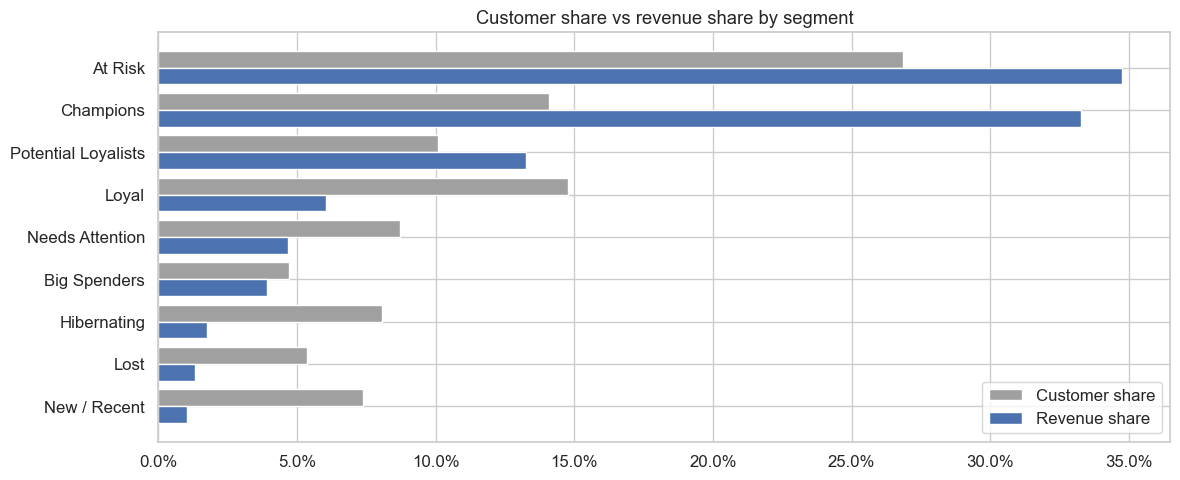

In [278]:
seg_summary = (
    rfm.groupby("segment")
    .agg(customers=("CUSTOMER", "count"),
         revenue=("monetary", "sum"))
    .assign(cust_share=lambda d: d["customers"]/d["customers"].sum(),
            rev_share =lambda d: d["revenue"]/d["revenue"].sum())
    .sort_values("revenue", ascending=False)
)

fig, ax = plt.subplots(figsize=FIGSIZE)
x = range(len(seg_summary))
w = 0.4
ax.barh([i - w/2 for i in x], seg_summary["cust_share"], w, label="Customer share", color="#A0A0A0")
ax.barh([i + w/2 for i in x], seg_summary["rev_share"],  w, label="Revenue share",  color=COLOR_PRIMARY)
ax.set_yticks(list(x))
ax.set_yticklabels(seg_summary.index)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Customer share vs revenue share by segment")
ax.legend()
plt.tight_layout()

print(seg_summary.assign(
    cust_share=lambda d: (d['cust_share']*100).round(1).astype(str) + '%',
    rev_share =lambda d: (d['rev_share']*100).round(1).astype(str) + '%',
))

**Interpretation**
- **Champions** are tiny in customer share but huge in revenue share — the gap between the two bars *is* customer value.
- **Lost** customers may dominate count but contribute near-zero revenue — that's the churn tax.
- **At Risk** is where the dashboard should drive action: the customer-share-vs-revenue-share gap quantifies the **revenue at stake if they fully churn.**
- Use the ratio `rev_share / cust_share` as a "value per customer" multiplier — anything above 1 is a profitable segment, below 1 is a cost center.

### Step 6 — Fulfilment method and B2B effect on AOV
Does Amazon fulfilment yield different basket sizes than Merchant? Does B2B?

Fulfilment AOV:
            count   mean
Fulfilment              
Amazon      78223 646.74
Merchant    32416 650.31

B2B AOV:
        count   mean
B2B                 
False  109841 647.40
True      798 701.00


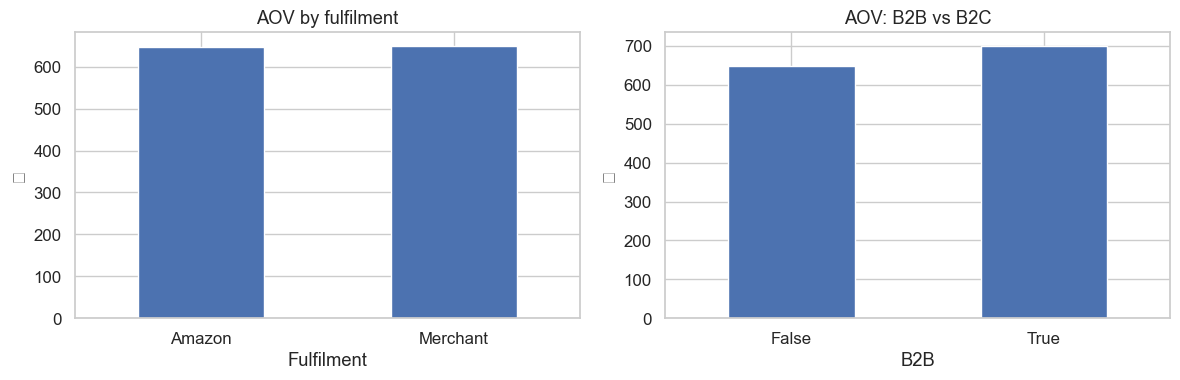

In [279]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

(amazon_clean.loc[~amazon_clean["is_cancelled"]]
 .groupby("Fulfilment")["revenue"].mean()
 .plot(kind="bar", ax=axes[0], color=COLOR_PRIMARY))
axes[0].set_title("AOV by fulfilment")
axes[0].set_ylabel("₹")
axes[0].tick_params(axis="x", rotation=0)

(amazon_clean.loc[~amazon_clean["is_cancelled"]]
 .groupby("B2B")["revenue"].mean()
 .plot(kind="bar", ax=axes[1], color=COLOR_PRIMARY))
axes[1].set_title("AOV: B2B vs B2C")
axes[1].set_ylabel("₹")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()

print("Fulfilment AOV:")
print(amazon_clean.loc[~amazon_clean["is_cancelled"]].groupby("Fulfilment")["revenue"].agg(["count", "mean"]))
print("\nB2B AOV:")
print(amazon_clean.loc[~amazon_clean["is_cancelled"]].groupby("B2B")["revenue"].agg(["count", "mean"]))

**Interpretation**
- **Amazon-fulfilled orders** (FBA) often have slightly higher AOV — Prime customers tend to add more items. If the gap is small, the channels are interchangeable.
- **B2B AOV** should be visibly higher than B2C — if it isn't, the "B2B" flag is either mislabeled or B2B isn't being merchandised differently.
- These two splits together suggest dashboard filters: a "Fulfilment" toggle and a "B2B/B2C" toggle let the analyst slice every other chart by these dimensions.

---
**Phase 6 takeaways feed Phase 7 (RFM deep-dive) and Phase 8 (export).** Note which charts surfaced the most decision-relevant signal — those are the ones that earn dashboard real estate.

---
## Phase 7 — RFM Analysis (Deep Dive)
> Phase 6 showed *how* segments compare in aggregate. Phase 7 goes inside RFM — examining the score distributions, segment profiles, champion vs lost contrasts, and the top customers worth naming on the dashboard.

### Step 1 — Segment profile table
Mean Recency / Frequency / Monetary per segment — turns the score map into plain-English benchmarks.

In [280]:
seg_profile = (
    rfm.groupby("segment")
    .agg(
        n_customers  =("CUSTOMER", "count"),
        avg_recency  =("recency",   "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary =("monetary",  "mean"),
        total_revenue=("monetary",  "sum"),
    )
    .round(1)
    .sort_values("total_revenue", ascending=False)
)

from pandas.io.formats.style import Styler
display(
    seg_profile.style.background_gradient(cmap="Blues", subset=["total_revenue", "avg_monetary"])
)

,n_customers,avg_recency,avg_frequency,avg_monetary,total_revenue
segment,,,,,
At Risk,40,244.200000,1.600000,137034.700000,5481389.000000
Champions,21,43.400000,4.400000,249772.100000,5245213.500000
Potential Loyalists,15,97.500000,2.000000,139499.200000,2092488.000000
Loyal,22,32.200000,1.400000,43306.900000,952751.600000
Needs Attention,13,105.600000,1.000000,56556.300000,735232.000000
Big Spenders,7,42.000000,1.000000,87848.300000,614938.000000
Hibernating,12,249.200000,1.000000,22887.000000,274644.000000
Lost,8,244.100000,1.000000,25818.100000,206545.000000
New / Recent,11,26.200000,1.000000,14996.500000,164961.100000


**Interpretation**
- Sort your eyes down **avg_recency** — the lower the number, the more recently they bought. Champions should be at the top (smallest recency); Lost at the bottom (largest).
- **avg_frequency** above 3–4 distinguishes truly loyal customers from one-hit wonders.
- **avg_monetary** tells you what each segment's average lifetime spend looks like — multiply by `n_customers` to get the segment's total revenue at stake.
- Any segment where `avg_recency` and `avg_frequency` are both *mid-range* is your highest-leverage marketing audience: they're engaged enough to respond, not so new that they're uncertain.

### Step 2 — R × F heatmap coloured by avg monetary
The classic RFM grid. Each cell is one (R_score, F_score) pair; the colour shows mean spend. Dark = high-value.

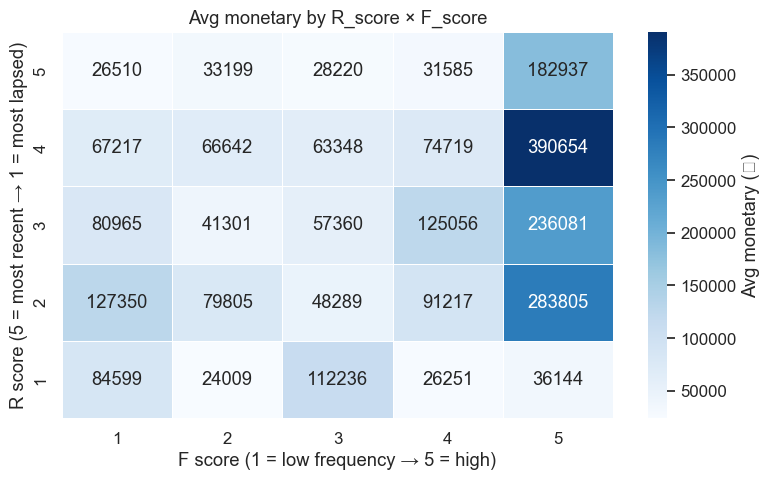

In [281]:
pivot = rfm.pivot_table(
    index="R_score", columns="F_score", values="monetary", aggfunc="mean"
).sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot, annot=True, fmt=".0f", cmap="Blues",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Avg monetary (₹)"}
)
ax.set_title("Avg monetary by R_score × F_score")
ax.set_xlabel("F score (1 = low frequency → 5 = high)")
ax.set_ylabel("R score (5 = most recent → 1 = most lapsed)")
plt.tight_layout()

**Interpretation**
- The **top-right corner** (R=5, F=5) is Champions — it should be the darkest cell. If it isn't, the segment rules need revisiting or the dataset has no true repeat-high-spenders.
- The **bottom-left corner** (R=1, F=1) is Lost — should be lightest (low spend, long gone).
- A **dark bottom-right cell** (R=1, F=5) = "At Risk" customers who bought frequently but haven't returned. These are your most important win-back targets because they demonstrated loyalty.
- A **dark top-left cell** (R=5, F=1) = big-spending newcomers — they need a strong post-purchase nurture sequence to convert to repeat buyers.

### Step 3 — Champions vs Lost: side-by-side distribution
The two extreme segments on every dimension. The gap is the business opportunity.

Champions:
       recency  frequency     monetary
count    21.00      21.00        21.00
mean     43.40       4.40   249,772.10
std      24.40       3.00   433,945.10
min       2.00       1.00    63,820.00
25%      19.00       3.00    78,300.00
50%      45.00       4.00   119,250.50
75%      64.00       5.00   215,279.00
max      76.00      11.00 2,094,070.50

Lost:
       recency  frequency  monetary
count     8.00       8.00      8.00
mean    244.10       1.00 25,818.10
std      62.40       0.00 14,400.10
min     148.00       1.00  5,580.00
25%     205.50       1.00 18,538.00
50%     232.50       1.00 27,470.50
75%     294.00       1.00 29,111.00
max     338.00       1.00 53,372.00


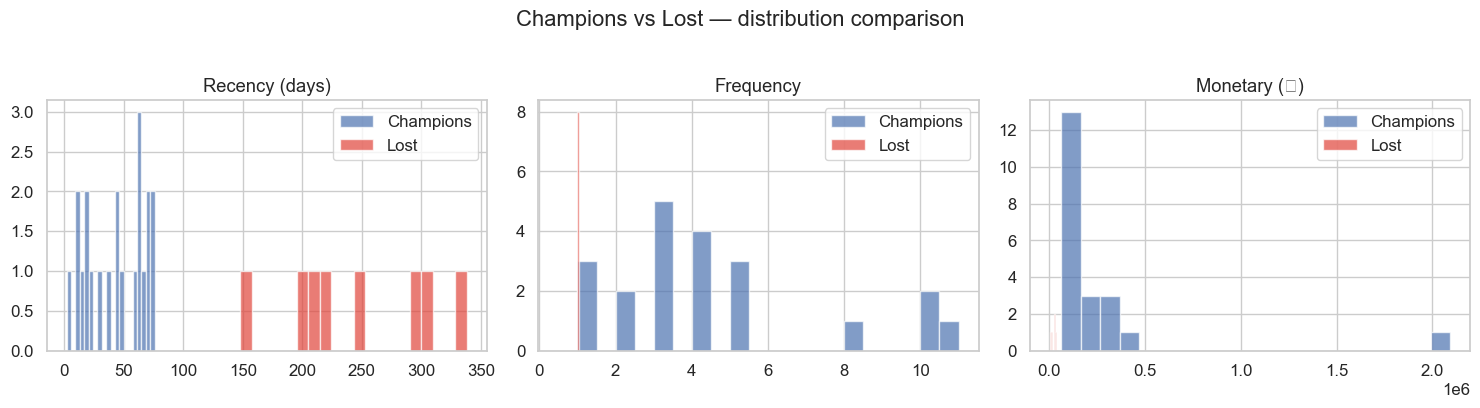

In [282]:
champ = rfm[rfm["segment"] == "Champions"]
lost  = rfm[rfm["segment"] == "Lost"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label in zip(axes,
                           ["recency", "frequency", "monetary"],
                           ["Recency (days)", "Frequency", "Monetary (₹)"]):
    ax.hist(champ[col], bins=20, alpha=0.7, label="Champions", color=COLOR_PRIMARY)
    ax.hist(lost[col],  bins=20, alpha=0.7, label="Lost",      color="#E0443A")
    ax.set_title(label)
    ax.legend()
plt.suptitle("Champions vs Lost — distribution comparison", y=1.02)
plt.tight_layout()

print("Champions:")
print(champ[["recency","frequency","monetary"]].describe().round(1))
print("\nLost:")
print(lost[["recency","frequency","monetary"]].describe().round(1))

**Interpretation**
- **Recency gap**: the distance between the two peaks is how far apart "active" and "lost" are in this dataset. If they overlap significantly, the 5-bin scoring isn't separating them clearly — try fewer bins.
- **Frequency gap**: if Champions and Lost both cluster at frequency=1, the dataset is too short a time window to measure repeat behaviour meaningfully via frequency alone.
- **Monetary gap**: this should be the starkest contrast. Champions spending 5–10× more than Lost is typical; a small gap means high-value lapsing customers weren't retained long enough to build spend.

### Step 4 — Top 20 customers by monetary
Dashboard-ready table. These are the accounts worth naming individually in the executive view.

In [283]:
top_customers = (
    rfm.sort_values("monetary", ascending=False)
    .head(20)
    [["CUSTOMER", "recency", "frequency", "monetary", "RFM_score", "segment"]]
    .assign(monetary=lambda d: d["monetary"].map("₹{:,.0f}".format))
    .reset_index(drop=True)
)
display(top_customers)

,CUSTOMER,recency,frequency,monetary,RFM_score,segment
0,Mulberries Boutique,37,10,"₹2,094,070",455,Champions
1,Amani Concept Trading Llc (Kapda),201,3,"₹930,451",255,At Risk
2,Vaharsha Boutique,89,4,"₹588,760",355,Potential Loyalists
3,Galaxy Group Of Companies Pvt. Ltd,220,1,"₹445,058",215,At Risk
4,Rivaan Llc,240,1,"₹443,042",135,At Risk
5,Bhanu Saleine Naunitham,13,4,"₹429,098",555,Champions
6,Sure Fashions Llc,281,1,"₹403,253",135,At Risk
7,Cotton Closet Ltd,307,1,"₹345,265",115,At Risk
8,Visha Devan,82,3,"₹321,028",355,Potential Loyalists
9,Nirusah Tailoring,219,1,"₹316,470",225,At Risk


**Interpretation**
- Check whether top spenders are in "Champions" or have drifted to "At Risk / Hibernating." A high-spend + high-recency mismatch = this account recently stopped buying after years of loyalty — the most urgent win-back case.
- `RFM_score` lets you rank precisely within a segment: 554 beats 543 even if both are "Champions." Use this for tiered outreach.

### Step 5 — Segment action map
Translate the analysis into the one-page view that drives dashboard design and marketing priorities.

In [284]:
action_map = {
    "Champions":            "Reward & upsell. Feature in referral programmes.",
    "Loyal":                "Offer loyalty tiers. Protect from competitors.",
    "Big Spenders":         "Push frequency. One re-purchase locks them in.",
    "New / Recent":         "Strong onboarding sequence. Second purchase is the goal.",
    "Potential Loyalists":  "Targeted nudge. Time-limited offer to reactivate.",
    "Needs Attention":      "Re-engagement campaign before they go cold.",
    "At Risk":              "Win-back email. Personalise with last category purchased.",
    "Hibernating":          "Low-cost reactivation. Accept a lower conversion rate.",
    "Lost":                 "Suppression list. Only re-market if CAC justifies it.",
}

action_df = (
    seg_profile
    .assign(action=lambda d: d.index.map(action_map))
    [["n_customers", "avg_recency", "avg_frequency", "avg_monetary", "total_revenue", "action"]]
)
display(action_df)

,n_customers,avg_recency,avg_frequency,avg_monetary,total_revenue,action
segment,,,,,,
At Risk,40,244.20,1.60,"137,034.70","5,481,389.00",Win-back email. Personalise with last category...
Champions,21,43.40,4.40,"249,772.10","5,245,213.50",Reward & upsell. Feature in referral programmes.
Potential Loyalists,15,97.50,2.00,"139,499.20","2,092,488.00",Targeted nudge. Time-limited offer to reactivate.
Loyal,22,32.20,1.40,"43,306.90","952,751.60",Offer loyalty tiers. Protect from competitors.
Needs Attention,13,105.60,1.00,"56,556.30","735,232.00",Re-engagement campaign before they go cold.
Big Spenders,7,42.00,1.00,"87,848.30","614,938.00",Push frequency. One re-purchase locks them in.
Hibernating,12,249.20,1.00,"22,887.00","274,644.00",Low-cost reactivation. Accept a lower conversi...
Lost,8,244.10,1.00,"25,818.10","206,545.00",Suppression list. Only re-market if CAC justif...
New / Recent,11,26.20,1.00,"14,996.50","164,961.10",Strong onboarding sequence. Second purchase is...


---
**Phase 7 complete.** The RFM model is fully built, profiled, and actionable. Phase 8 packages these outputs for the dashboard.

---
## Phase 8 — Dashboard Prep & Export
> Standardise column names, trim to dashboard-relevant columns, and write clean CSVs the dashboard layer can consume directly.

Three exports:
| File | Used for |
|---|---|
| `amazon_dashboard.csv` | Sales KPIs, time series, geography, category, status |
| `customer_rfm.csv` | RFM segments, top-customer view |
| `catalog_clean.csv` | Product metadata join for SKU-level drill-downs |

### Step 1 — Finalise amazon_dashboard
Select the columns the dashboard will actually use, rename to readable labels, and reorder.

In [285]:
amazon_dashboard = (
    amazon_clean
    [[
        "Order ID", "Date", "order_month", "order_dow",
        "Category", "Size", "SKU", "ASIN",
        "Fulfilment", "ship-service-level",
        "Courier Status", "Status",
        "is_shipped", "is_cancelled", "is_returned",
        "Qty", "revenue", "B2B",
        "ship-city", "ship-state", "ship-postal-code", "ship-country",
    ]]
    .rename(columns={
        "Order ID":           "order_id",
        "Date":               "date",
        "ship-service-level": "service_level",
        "Courier Status":     "courier_status",
        "Status":             "status",
        "Qty":                "qty",
        "ship-city":          "city",
        "ship-state":         "state",
        "ship-postal-code":   "postal_code",
        "ship-country":       "country",
    })
)

print(f"amazon_dashboard: {amazon_dashboard.shape[0]:,} rows × {amazon_dashboard.shape[1]} cols")
amazon_dashboard.dtypes

amazon_dashboard: 128,968 rows × 22 cols


order_id                     str
date              datetime64[us]
order_month                  str
order_dow                    str
Category                     str
Size                         str
SKU                          str
ASIN                         str
Fulfilment                   str
service_level                str
courier_status               str
status                       str
is_shipped                  bool
is_cancelled                bool
is_returned                 bool
qty                        int64
revenue                  float64
B2B                         bool
city                         str
state                        str
postal_code               object
country                      str
dtype: object

**Column rationale**
- `order_month` / `order_dow` are pre-computed so the dashboard doesn't need date logic.
- `is_shipped / is_cancelled / is_returned` are the collapsed flags — simpler than regex on Status at query time.
- `revenue` is already 0 for all non-revenue events; no filter needed on the dashboard side.
- Dropped: `fulfilled-by`, `promotion-ids`, `Sales Channel`, `Unnamed: 22` — all single-value or mostly null.

### Step 2 — Finalise customer_rfm

In [286]:
customer_rfm = (
    rfm
    .rename(columns={"CUSTOMER": "customer"})
    [[
        "customer", "recency", "frequency", "monetary",
        "R_score", "F_score", "M_score", "RFM_score", "segment",
    ]]
    .sort_values("monetary", ascending=False)
    .reset_index(drop=True)
)

print(f"customer_rfm: {customer_rfm.shape[0]:,} rows × {customer_rfm.shape[1]} cols")
customer_rfm.head()

customer_rfm: 149 rows × 9 cols


,customer,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,Mulberries Boutique,37,10,"2,094,070.50",4,5,5,455,Champions
1,Amani Concept Trading Llc (Kapda),201,3,"930,451.00",2,5,5,255,At Risk
2,Vaharsha Boutique,89,4,"588,760.00",3,5,5,355,Potential Loyalists
3,Galaxy Group Of Companies Pvt. Ltd,220,1,"445,058.00",2,1,5,215,At Risk
4,Rivaan Llc,240,1,"443,042.00",1,3,5,135,At Risk


### Step 3 — Finalise catalog_clean

In [287]:
catalog_export = (
    catalog_clean
    .rename(columns={
        "SKU Code":  "SKU",
        "Design No.": "design_no",
        "Stock":      "stock",
        "Category":   "category",
        "Size":       "size",
        "Color":      "color",
    })
    .drop(columns=["index"], errors="ignore")
    .reset_index(drop=True)
)

print(f"catalog_export: {catalog_export.shape[0]:,} rows × {catalog_export.shape[1]} cols")
catalog_export.head()

catalog_export: 9,271 rows × 6 cols


,SKU,design_no,stock,category,size,color
0,AN201-RED-L,AN201,5.00,AN : LEGGINGS,L,Red
1,AN201-RED-M,AN201,5.00,AN : LEGGINGS,M,Red
2,AN201-RED-S,AN201,3.00,AN : LEGGINGS,S,Red
3,AN201-RED-XL,AN201,6.00,AN : LEGGINGS,XL,Red
4,AN201-RED-XXL,AN201,3.00,AN : LEGGINGS,XXL,Red


### Step 4 — Final quality gate
Before writing to disk, confirm there are no last-minute nulls or type issues in any export.

In [288]:
exports = {
    "amazon_dashboard": amazon_dashboard,
    "customer_rfm":     customer_rfm,
    "catalog_export":   catalog_export,
}

all_clear = True
for name, df in exports.items():
    nulls      = df.isna().sum().sum()
    null_cols  = df.columns[df.isna().any()].tolist()
    dupe_rows  = df.duplicated().sum()
    print(f"{'✓' if nulls == 0 else '⚠'} {name:22s} "
          f"{df.shape[0]:>7,} × {df.shape[1]:>2}   "
          f"nulls={nulls:,}  dupes={dupe_rows:,}"
          + (f"   null_cols={null_cols}" if null_cols else ""))
    if nulls > 0 or dupe_rows > 0:
        all_clear = False

print()
print("✓ All exports clean — ready to write." if all_clear else
      "⚠ Review flagged issues above before exporting.")

⚠ amazon_dashboard       128,968 × 22   nulls=7,004  dupes=0   null_cols=['courier_status', 'city', 'state', 'postal_code', 'country']
✓ customer_rfm               149 ×  9   nulls=0  dupes=0
⚠ catalog_export           9,271 ×  6   nulls=296  dupes=38   null_cols=['SKU', 'design_no', 'stock', 'category', 'size', 'color']

⚠ Review flagged issues above before exporting.


**What to do if the gate flags issues**
- **Nulls in `amazon_dashboard`** — most expected ones are `postal_code` (33 rows with no shipping address). These are safe to leave; the dashboard can handle them with a fallback "Unknown" label.
- **Nulls in `customer_rfm`** — shouldn't exist after Phase 3 dropping misaligned rows. If they appear, trace back to the `groupby` in Phase 4 Step 6.
- **Nulls in `catalog_export`** — `stock` and `color` have legitimate NaNs from the source. Acceptable unless the dashboard tries to aggregate on them.

### Step 5 — Write to disk

In [289]:
import os
out_dir = "csv/clean"
os.makedirs(out_dir, exist_ok=True)

amazon_dashboard.to_csv(f"{out_dir}/amazon_dashboard.csv", index=False)
customer_rfm.to_csv(    f"{out_dir}/customer_rfm.csv",     index=False)
catalog_export.to_csv(  f"{out_dir}/catalog_export.csv",   index=False)

for name, df in exports.items():
    path_out = f"{out_dir}/{name}.csv"
    size_kb = os.path.getsize(path_out) / 1024
    print(f"  ✓ {path_out:45s} {size_kb:>7.1f} KB")

  ✓ csv/clean/amazon_dashboard.csv                22786.4 KB
  ✓ csv/clean/customer_rfm.csv                        7.5 KB
  ✓ csv/clean/catalog_export.csv                    379.2 KB


### Step 6 — EDA complete: summary of findings

In [290]:
print("=" * 60)
print("  EDA COMPLETE — Summary of Key Findings")
print("=" * 60)

total_rev = amazon_dashboard.loc[~amazon_dashboard["is_cancelled"], "revenue"].sum()
cancel_rate = amazon_dashboard["is_cancelled"].mean()
return_rate = amazon_dashboard["is_returned"].mean()
top_cat = amazon_dashboard.groupby("Category")["revenue"].sum().idxmax()
top_state = amazon_dashboard.loc[~amazon_dashboard["is_cancelled"]].groupby("state")["revenue"].sum().idxmax()
n_customers = customer_rfm.shape[0]
pct_one_time = (customer_rfm["frequency"] == 1).mean()
champ_rev_share = (
    customer_rfm.loc[customer_rfm["segment"] == "Champions", "monetary"].sum()
    / customer_rfm["monetary"].sum()
)

print(f"  Total Amazon revenue (non-cancelled): ₹{total_rev:,.0f}")
print(f"  Cancellation rate:                    {cancel_rate:.1%}")
print(f"  Return rate:                           {return_rate:.1%}")
print(f"  Top revenue category:                  {top_cat}")
print(f"  Top revenue state:                     {top_state}")
print(f"  RFM customers:                         {n_customers:,}")
print(f"  One-time buyers:                       {pct_one_time:.0%}")
print(f"  Champions revenue share:               {champ_rev_share:.0%}")
print()
print("  Exports written to csv/clean/")
print("=" * 60)

  EDA COMPLETE — Summary of Key Findings
  Total Amazon revenue (non-cancelled): ₹71,670,272
  Cancellation rate:                    14.2%
  Return rate:                           1.6%
  Top revenue category:                  Set
  Top revenue state:                     Maharashtra
  RFM customers:                         149
  One-time buyers:                       69%
  Champions revenue share:               33%

  Exports written to csv/clean/


---
### Next steps — Dashboard build

The three CSVs in `csv/clean/` are the single source of truth for the dashboard layer.

| Dashboard view | Primary table | Key columns |
|---|---|---|
| Sales overview (KPIs) | `amazon_dashboard` | `revenue`, `is_cancelled`, `date` |
| Time series | `amazon_dashboard` | `order_month`, `revenue`, `Category` |
| Geography map | `amazon_dashboard` | `state`, `revenue` |
| Category / size drill-down | `amazon_dashboard` | `Category`, `Size`, `revenue` |
| Customer segments | `customer_rfm` | `segment`, `monetary`, `recency` |
| Top customers | `customer_rfm` | `customer`, `monetary`, `RFM_score` |
| Product lookup | `catalog_export` | `SKU`, `stock`, `color` |

Recommended dashboard tool: **Plotly Dash** (keeps everything in Python, reuses chart code from this notebook) or **Power BI / Tableau** (faster for non-code stakeholders, connect directly to the CSVs).